In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import cartopy.crs as ccrs
import matplotlib.colors as mcolors
import cartopy.mpl.ticker as cticker
import timeit
import warnings
warnings.filterwarnings("ignore")

In [2]:
# filepath = "/Users/sdutta/OneDrive - Johns Hopkins/Documents/ML-Plankton/"
filepath = "C:/Users/dutts/OneDrive - Johns Hopkins/Documents/ML-Plankton/"

In [3]:
data = xr.open_dataset(filepath + "kostadinov/data/DataLog10T_final.nc")

In [4]:
data

<xarray.Dataset> Size: 62MB
Dimensions:   (lon: 360, lat: 162, month: 12)
Coordinates:
  * lon       (lon) float64 3kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
  * lat       (lat) float64 1kB -77.5 -76.5 -75.5 -74.5 ... 80.5 81.5 82.5 83.5
  * month     (month) uint64 96B 1 2 3 4 5 6 7 8 9 10 11 12
Data variables:
    dfe       (lon, lat, month) float64 6MB ...
    mld       (lon, lat, month) float64 6MB ...
    nh4       (lon, lat, month) float64 6MB ...
    no3       (lon, lat, month) float64 6MB ...
    po4       (lon, lat, month) float64 6MB ...
    rsn       (lon, lat, month) float64 6MB ...
    tos       (lon, lat, month) float64 6MB ...
    sos       (lon, lat, month) float64 6MB ...
    wo5       (lon, lat, month) float64 6MB ...
    si        (lon, lat, month) float64 6MB ...
    Log10Phc  (lon, lat, month) float64 6MB ...

In [5]:
data = data.rename({'tos':'sst','sos':'sal','si':'sil','wo5':'w50','Log10Phc':'logphyc'})

In [6]:
def convert360_180(ds):
    """
    convert longitude from 0-360 to -180-180
    """
    #check if already 
    attrs = ds['lon'].attrs
    if ds['lon'].min()>= 0:
        with xr.set_options(keep_attrs=True):
            ds.coords['lon'] = (ds['lon'] + 180) % 360 - 180
        ds = ds.sortby('lon')
    return ds

In [7]:
data = convert360_180(data)

In [8]:
dsin = data.drop_vars('logphyc')

In [9]:
dfin = dsin.to_dataframe()
dfin = dfin.loc[:,['dfe','mld','nh4','no3','po4','rsn','sal','sst','sil','w50']]
dfin = dfin.dropna()
dfin.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 431112 entries, (-77.5, 1, -178.5) to (83.5, 12, -22.5)
Data columns (total 10 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   dfe     431112 non-null  float64
 1   mld     431112 non-null  float64
 2   nh4     431112 non-null  float64
 3   no3     431112 non-null  float64
 4   po4     431112 non-null  float64
 5   rsn     431112 non-null  float64
 6   sal     431112 non-null  float64
 7   sst     431112 non-null  float64
 8   sil     431112 non-null  float64
 9   w50     431112 non-null  float64
dtypes: float64(10)
memory usage: 35.0 MB


In [10]:
corr_inputs = np.round(dfin.corr(), 2)

 np.zeros_like() returns an array of zeros with the same shape and type as the given array. By passing in the correlation matrix, we get an array of zeros.
 The dtype=np.bool parameter overrides the data type, so our array is an array of booleans. np.triu_indices_from(mask) returns the indices for the upper triangle of the array.  Now, we set the upper triangle to True. mask[np.triu_indices_from(mask)]= True

mask = np.zeros_like(corr_inputs, dtype=bool)
mask[np.triu_indices_from(mask)]= True

f, ax = plt.subplots(figsize=(10, 10))

heatmap = sns.heatmap(corr_inputs, ax=ax,
                      mask = mask,
                      square = True,
                      linewidths = .5,
                      cmap = 'coolwarm',
                      cbar_kws = {'shrink': 0.7,
                                'ticks' : np.linspace(-1, 1, 21)},
                      vmin = -1,
                      vmax = 1,
                      annot = True,
                      annot_kws = {'size': 10}
                     )

#add the column names as labels
ax.set_yticklabels(corr_inputs.columns, rotation = 0)
ax.set_xticklabels(corr_inputs.columns)

sns.set_style({'xtick.bottom': True}, {'ytick.left': True})
f.savefig(filepath + "copernicus/charts/corr_inputs.jpg",dpi=200, bbox_inches='tight')

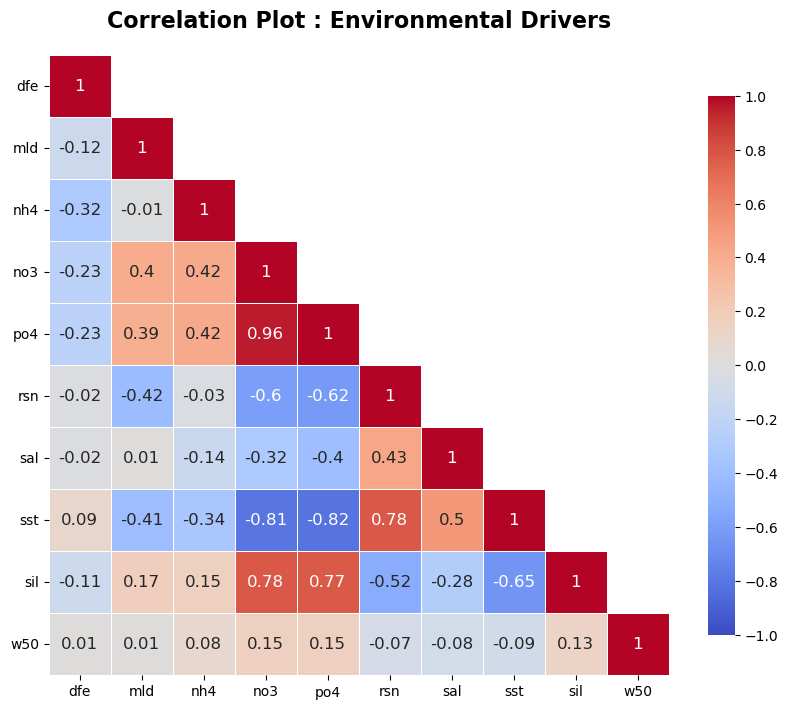

In [11]:
# Only mask upper triangle *excluding* diagonal
mask = np.triu(np.ones_like(corr_inputs, dtype=bool), k=1)
# mask = np.zeros_like(corr_inputs, dtype=bool)
# mask[np.triu_indices_from(mask)]= True

f, ax = plt.subplots(figsize=(10, 10))

heatmap = sns.heatmap(corr_inputs, ax=ax,
                      mask = mask,
                      square = True,
                      linewidths = .5,
                      cmap = 'coolwarm',
                      cbar = True,
                      cbar_kws = {'shrink': 0.7,'ticks' : np.linspace(-1, 1, 11)},
                      vmin = -1,
                      vmax = 1,
                      annot = True,
                      annot_kws = {'size': 12}
                     )
ax.set_title("Correlation Plot : Environmental Drivers", fontsize=16,fontweight='bold', pad=20)
#add the column names as labels
ax.set_yticklabels(corr_inputs.columns, rotation = 0)
ax.set_xticklabels(corr_inputs.columns)

sns.set_style({'xtick.bottom': True}, {'ytick.left': True})
# f.savefig(filepath + "copernicus/charts/corr_inputs.jpg",dpi=200, bbox_inches='tight')

### Copernicus Data Wrangling

#### Copernicus - No Fill

In [12]:
# file_list = []
# path = filepath + "copernicus/20??_cmems_obs-oc_glo_bgc-plankton_my_l4-multi-4km_P1M.nc"
# for file in sorted(glob.glob(path)):
#     print(file)
#     ds = xr.open_dataset(file, engine='netcdf4')
#     file_list.append(ds)

In [13]:
# coper = xr.merge(file_list)
# coper

In [14]:
# cop = coper.groupby(coper['time'].dt.month).mean(dim='time')
# cop = cop.drop_vars('DINO')

In [15]:
cop = xr.open_dataset("2010-2023_cmems_obs-oc_glo_bgc-plankton_my_l4-multi-4km_P1M.nc")

In [16]:
# cop = cop.drop_vars(['DINO'])

In [17]:
dc = xr.merge([dsin, cop], join='inner')
dc = dc.transpose('month','lon','lat')
dc

<xarray.Dataset> Size: 84MB
Dimensions:  (lat: 162, month: 12, lon: 360)
Coordinates:
  * lat      (lat) float64 1kB -77.5 -76.5 -75.5 -74.5 ... 80.5 81.5 82.5 83.5
  * month    (month) uint64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * lon      (lon) float64 3kB -179.5 -178.5 -177.5 -176.5 ... 177.5 178.5 179.5
Data variables: (12/15)
    dfe      (month, lon, lat) float64 6MB nan 1.946e-07 1.924e-07 ... nan nan
    mld      (month, lon, lat) float64 6MB nan 62.59 54.19 46.74 ... nan nan nan
    nh4      (month, lon, lat) float64 6MB nan 0.0005597 0.0004663 ... nan nan
    no3      (month, lon, lat) float64 6MB nan 0.01825 0.02021 ... nan nan nan
    po4      (month, lon, lat) float64 6MB nan 0.001395 0.001503 ... nan nan nan
    rsn      (month, lon, lat) float64 6MB nan 169.4 173.4 162.0 ... nan nan nan
    ...       ...
    sil      (month, lon, lat) float64 6MB nan 0.06223 0.05972 ... nan nan nan
    CHL      (month, lon, lat) float64 6MB ...
    DIATO    (month, lon, lat) float64 6MB ...
    MICRO    (month, lon, lat) float64 6MB ...
    NANO     (month, lon, lat) float64 6MB ...
    PICO     (month, lon, lat) float64 6MB ...

In [18]:
dc = dc.rename({'CHL':'chla','DIATO':'diat','MICRO':'mcro','NANO':'nano','PICO':'pico'})

In [19]:
dc_nonfill = dc.copy()

In [20]:
dc_nonfill['logchla'] = np.log10(dc_nonfill['chla'])
dc_nonfill['logdiat'] = np.log10(dc_nonfill['diat'])
dc_nonfill['logmcro'] = np.log10(dc_nonfill['mcro'])
dc_nonfill['lognano'] = np.log10(dc_nonfill['nano'])
dc_nonfill['logpico'] = np.log10(dc_nonfill['pico'])

In [21]:
# dc_nonfill.to_netcdf("2010-2021_cmems_bgc_plankton_no_fill.nc")

In [22]:
dfc = dc_nonfill.to_dataframe()
dfc = dfc.astype("float32")
dfc_nonfill = dfc.dropna()
dfc_nonfill.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 371700 entries, (-77.5, 1, -178.5) to (82.5, 8, 81.5)
Data columns (total 20 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   dfe      371700 non-null  float32
 1   mld      371700 non-null  float32
 2   nh4      371700 non-null  float32
 3   no3      371700 non-null  float32
 4   po4      371700 non-null  float32
 5   rsn      371700 non-null  float32
 6   sst      371700 non-null  float32
 7   sal      371700 non-null  float32
 8   w50      371700 non-null  float32
 9   sil      371700 non-null  float32
 10  chla     371700 non-null  float32
 11  diat     371700 non-null  float32
 12  mcro     371700 non-null  float32
 13  nano     371700 non-null  float32
 14  pico     371700 non-null  float32
 15  logchla  371700 non-null  float32
 16  logdiat  371700 non-null  float32
 17  logmcro  371700 non-null  float32
 18  lognano  371700 non-null  float32
 19  logpico  371700 non-null  float32
dtype

In [23]:
dcm_nonfill = dc_nonfill.mean(dim='month')

#### Copernicus - One percent Fill

In [24]:
dc1 = dc.copy()

In [25]:
variables = ['chla','diat','mcro','nano','pico']
fill ={}
for var in variables:
    fill[f'{var}_fill'] = dc1[var].quantile(0.01, dim=None).values

In [26]:
fill

{'chla_fill': array(0.02542355),
 'diat_fill': array(0.00356524),
 'mcro_fill': array(0.00679165),
 'nano_fill': array(0.01135866),
 'pico_fill': array(0.03731255)}

In [27]:
for var in variables:
    dc1[var] = dc1[var].fillna(fill[f'{var}_fill'])

In [28]:
dfc1 = dc1.to_dataframe()
dfc1.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 699840 entries, (-77.5, 1, -179.5) to (83.5, 12, 179.5)
Data columns (total 15 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   dfe     431112 non-null  float64
 1   mld     431112 non-null  float64
 2   nh4     431112 non-null  float64
 3   no3     431112 non-null  float64
 4   po4     431112 non-null  float64
 5   rsn     431112 non-null  float64
 6   sst     431112 non-null  float64
 7   sal     431112 non-null  float64
 8   w50     431112 non-null  float64
 9   sil     431112 non-null  float64
 10  chla    699840 non-null  float64
 11  diat    699840 non-null  float64
 12  mcro    699840 non-null  float64
 13  nano    699840 non-null  float64
 14  pico    699840 non-null  float64
dtypes: float64(15)
memory usage: 83.4 MB


In [29]:
# dfc1 = dfc1.drop("DINO", axis=1)
dfc_fillone = dfc1.dropna()
dfc_fillone = dfc_fillone.astype('float32')
dfc_fillone.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 431112 entries, (-77.5, 1, -178.5) to (83.5, 12, -22.5)
Data columns (total 15 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   dfe     431112 non-null  float32
 1   mld     431112 non-null  float32
 2   nh4     431112 non-null  float32
 3   no3     431112 non-null  float32
 4   po4     431112 non-null  float32
 5   rsn     431112 non-null  float32
 6   sst     431112 non-null  float32
 7   sal     431112 non-null  float32
 8   w50     431112 non-null  float32
 9   sil     431112 non-null  float32
 10  chla    431112 non-null  float32
 11  diat    431112 non-null  float32
 12  mcro    431112 non-null  float32
 13  nano    431112 non-null  float32
 14  pico    431112 non-null  float32
dtypes: float32(15)
memory usage: 26.7 MB


In [30]:
for var in variables:
    dfc_fillone[f'log{var}'] = np.log10(dfc_fillone[var])

In [31]:
dfc_fillone.head()

dfe        mld       nh4       no3       po4  \
lat   month lon                                                             
-77.5 1     -178.5  2.679019e-07  77.747002  0.000551  0.016134  0.001235   
            -177.5  2.644416e-07  75.447998  0.000523  0.016679  0.001251   
            -176.5  2.960231e-07  73.435997  0.000496  0.017200  0.001268   
            -175.5  2.617441e-07  71.829002  0.000470  0.017657  0.001283   
            -174.5  3.002942e-07  70.742996  0.000440  0.018044  0.001296   

                           rsn      sst        sal           w50       sil  \
lat   month lon                                                              
-77.5 1     -178.5  130.119232 -0.25111  34.274502  8.775279e-07  0.058165   
            -177.5  125.292305 -0.30951  34.261688  7.140983e-07  0.057787   
            -176.5  127.242310 -0.36131  34.249710  1.770336e-07  0.057461   
            -175.5  127.242310 -0.40501  34.238689 -5.363125e-07  0.057123   
            -174.5  121.280769 -0.44010  34.228912 -1.706607e-06  0.056761   

                        chla      diat      mcro      nano      pico  \
lat   month lon                                                        
-77.5 1     -178.5  1.161823  4.171545  4.223311  0.136021  0.160340   
            -177.5  1.264481  2.177002  2.258741  0.170274  0.179286   
            -176.5  1.258695  1.213927  1.295848  0.231647  0.176216   
            -175.5  1.233465  1.934669  2.010873  0.156743  0.169910   
            -174.5  1.460254  1.436142  1.521730  0.188898  0.178811   

                     logchla   logdiat   logmcro   lognano   logpico  
lat   month lon                                                       
-77.5 1     -178.5  0.065140  0.620297  0.625653 -0.866395 -0.794957  
            -177.5  0.101912  0.337859  0.353867 -0.768851 -0.746455  
            -176.5  0.099921  0.084192  0.112554 -0.635173 -0.753953  
            -175.5  0.091127  0.286607  0.303385 -0.804812 -0.769782  
            -174.5  0.164428  0.157198  0.182338 -0.723773 -0.747605

In [32]:
dc_fillone = dfc_fillone.to_xarray()

In [33]:
# dc_fillone.to_netcdf("2010-2023_cmems_bgc_plankton_one-percentile_fill.nc")

In [34]:
dcm_fillone = dc_fillone.mean(dim='month')

#### Copernicus - Variable Fill (lower of the min value and 10% of max value at each lat/lon)

In [35]:
dc2 = dc.copy()

In [36]:
# List of variables to process
variables = ['chla', 'diat', 'mcro', 'nano', 'pico']

for var in variables:
    # Get min and max over 'month' at each (lat, lon)
    min_val = dc2[var].min(dim='month', skipna=True)
    max_val = dc2[var].max(dim='month', skipna=True)
    # print(min_val.shape, max_val.shape)
    
    # Compute 10% of max
    max10 = 0.1 * max_val

    # Take the minimum of (min_val, 10% of max_val)
    fill_val = xr.where(min_val < max10, min_val, max10)
    # print(fill_val.shape)

    # Expand back to (month, lat, lon)
    fill_val_broadcast = fill_val.expand_dims(month=dc2.month).transpose('month', 'lat', 'lon')

    # Replace NaNs with this value
    dc2[var] = dc2[var].fillna(fill_val_broadcast)

In [37]:
dfc2 = dc2.to_dataframe()
dfc2 = dfc2.astype('float32')
dfc2.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 699840 entries, (-77.5, 1, -179.5) to (83.5, 12, 179.5)
Data columns (total 15 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   dfe     431112 non-null  float32
 1   mld     431112 non-null  float32
 2   nh4     431112 non-null  float32
 3   no3     431112 non-null  float32
 4   po4     431112 non-null  float32
 5   rsn     431112 non-null  float32
 6   sst     431112 non-null  float32
 7   sal     431112 non-null  float32
 8   w50     431112 non-null  float32
 9   sil     431112 non-null  float32
 10  chla    479460 non-null  float32
 11  diat    481032 non-null  float32
 12  mcro    481032 non-null  float32
 13  nano    481032 non-null  float32
 14  pico    481032 non-null  float32
dtypes: float32(15)
memory usage: 43.4 MB


In [38]:
# dfc2 = dfc2.drop('DINO', axis=1)
dfc_fillvar = dfc2.dropna()
dfc_fillvar.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 430620 entries, (-77.5, 1, -178.5) to (82.5, 12, 81.5)
Data columns (total 15 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   dfe     430620 non-null  float32
 1   mld     430620 non-null  float32
 2   nh4     430620 non-null  float32
 3   no3     430620 non-null  float32
 4   po4     430620 non-null  float32
 5   rsn     430620 non-null  float32
 6   sst     430620 non-null  float32
 7   sal     430620 non-null  float32
 8   w50     430620 non-null  float32
 9   sil     430620 non-null  float32
 10  chla    430620 non-null  float32
 11  diat    430620 non-null  float32
 12  mcro    430620 non-null  float32
 13  nano    430620 non-null  float32
 14  pico    430620 non-null  float32
dtypes: float32(15)
memory usage: 26.7 MB


In [39]:
for var in variables:
    dfc_fillvar[f'log{var}'] = np.log10(dfc_fillvar[var])

In [40]:
dc_fillvar = dfc_fillvar.to_xarray()

In [41]:
# dc_fillvar.to_netcdf("2010-2023_cmems_bgc_plankton_variable_fill.nc")

In [42]:
dcm_fillvar = dc_fillvar.mean(dim='month')

#### Copernicus - Comparison of no fill to one-percentile filling and variable fill

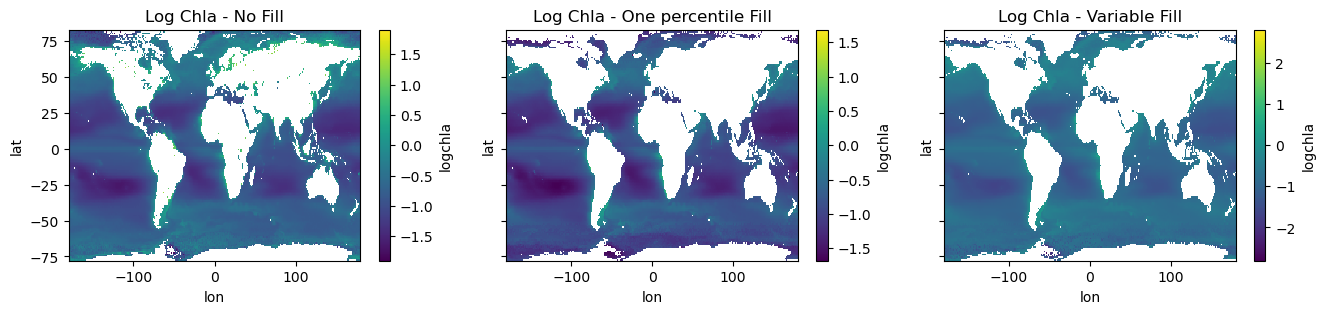

In [43]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16,3), sharey=True, dpi=100)
dcm_nonfill['logchla'].T.plot(ax=ax1, cmap='viridis')
dcm_fillone['logchla'].plot(ax=ax2, cmap='viridis')
dcm_fillvar['logchla'].plot(ax=ax3, cmap='viridis')
ax1.set_title("Log Chla - No Fill")
ax2.set_title("Log Chla - One percentile Fill")
ax3.set_title("Log Chla - Variable Fill")
plt.show()

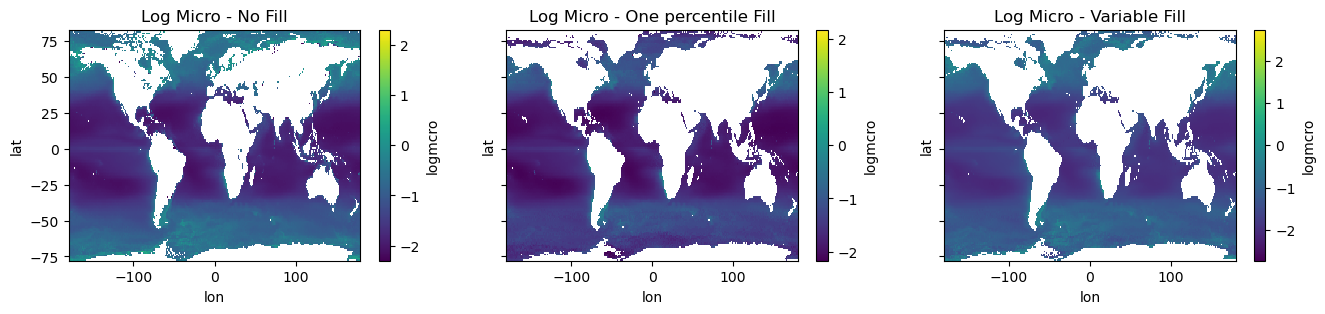

In [44]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16,3), sharey=True, dpi=100)
dcm_nonfill['logmcro'].T.plot( ax=ax1, cmap='viridis')
dcm_fillone['logmcro'].plot(ax=ax2, cmap='viridis')
dcm_fillvar['logmcro'].plot(ax=ax3, cmap='viridis')
ax1.set_title("Log Micro - No Fill")
ax2.set_title("Log Micro - One percentile Fill")
ax3.set_title("Log Micro - Variable Fill")
plt.show()

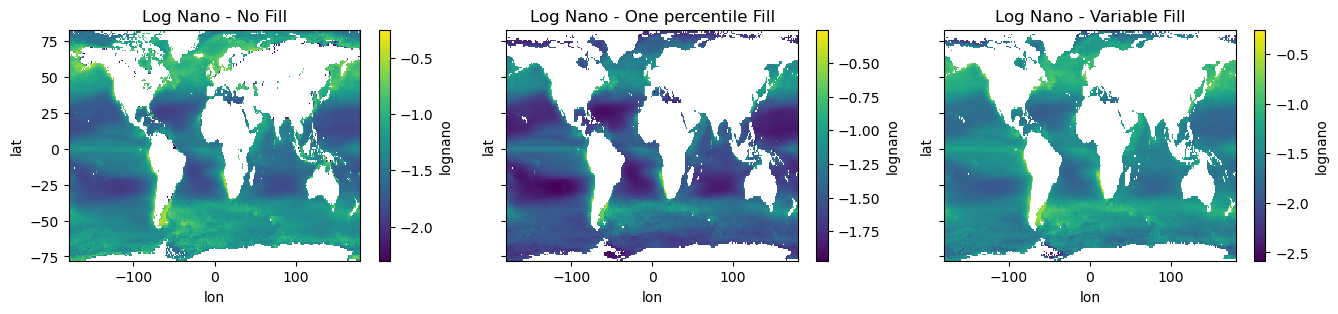

In [45]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16,3), sharey=True, dpi=100)
dcm_nonfill['lognano'].T.plot(ax=ax1, cmap='viridis')
dcm_fillone['lognano'].plot(ax=ax2, cmap='viridis')
dcm_fillvar['lognano'].plot(ax=ax3, cmap='viridis')
ax1.set_title("Log Nano - No Fill")
ax2.set_title("Log Nano - One percentile Fill")
ax3.set_title("Log Nano - Variable Fill")
plt.show()

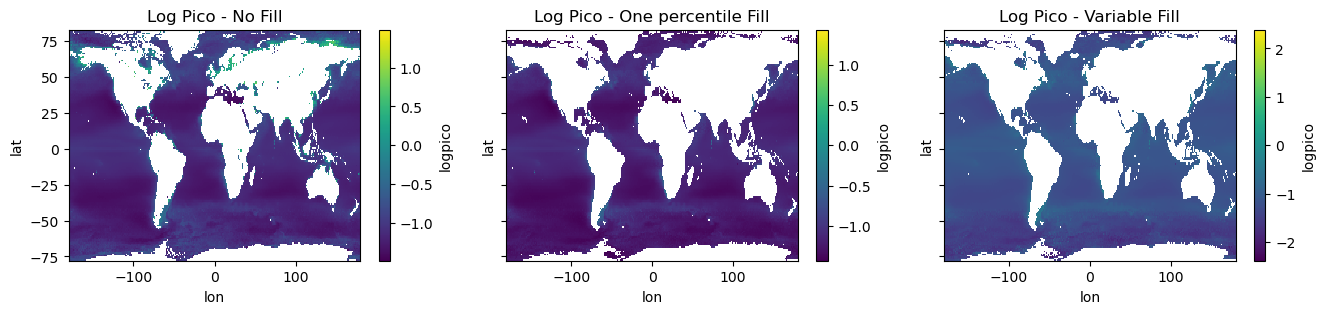

In [46]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16,3), sharey=True, dpi=100)
dcm_nonfill['logpico'].T.plot(ax=ax1, cmap='viridis')
dcm_fillone['logpico'].plot(ax=ax2, cmap='viridis')
dcm_fillvar['logpico'].plot(ax=ax3, cmap='viridis')
ax1.set_title("Log Pico - No Fill")
ax2.set_title("Log Pico - One percentile Fill")
ax3.set_title("Log Pico - Variable Fill")
plt.show()

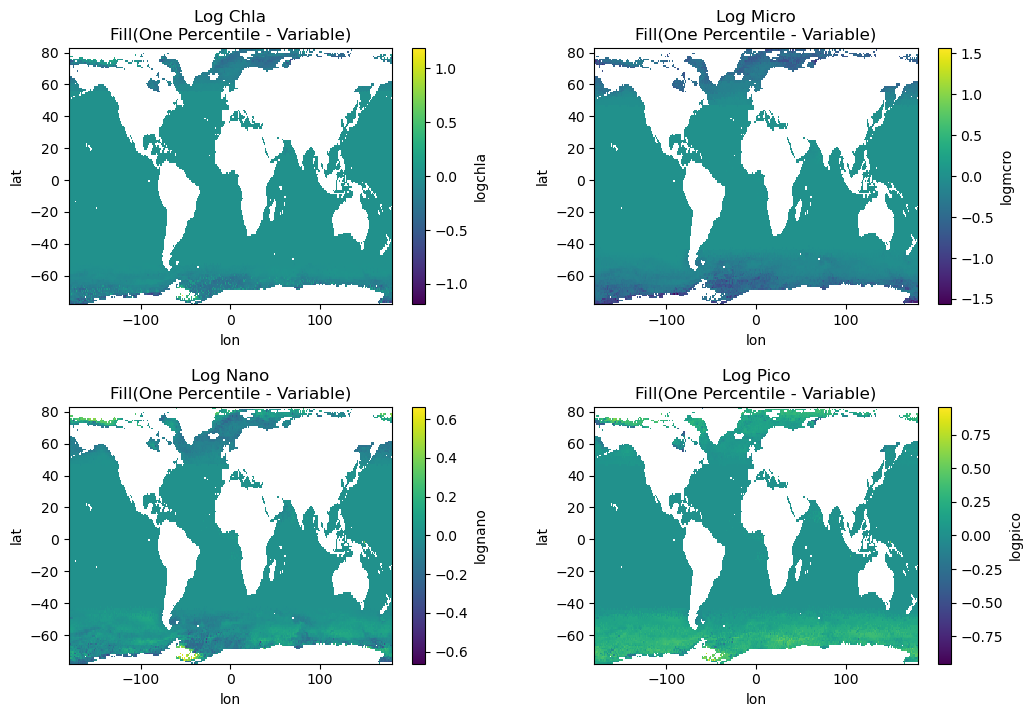

In [47]:
fig, ax = plt.subplots(2,2, figsize=(12,8), dpi=100)

(dcm_fillone['logchla'] - dcm_fillvar['logchla']).plot(ax=ax[0,0], cmap='viridis')
(dcm_fillone['logmcro'] - dcm_fillvar['logmcro']).plot(ax=ax[0,1], cmap='viridis')
(dcm_fillone['lognano'] - dcm_fillvar['lognano']).plot(ax=ax[1,0], cmap='viridis')
(dcm_fillone['logpico'] - dcm_fillvar['logpico']).plot(ax=ax[1,1], cmap='viridis')

ax[0,0].set_title("Log Chla\nFill(One Percentile - Variable)")
ax[0,1].set_title("Log Micro\nFill(One Percentile - Variable)")
ax[1,0].set_title("Log Nano\nFill(One Percentile - Variable)")
ax[1,1].set_title("Log Pico\nFill(One Percentile - Variable)")
plt.subplots_adjust(wspace=0.3, hspace=0.4)
plt.show()

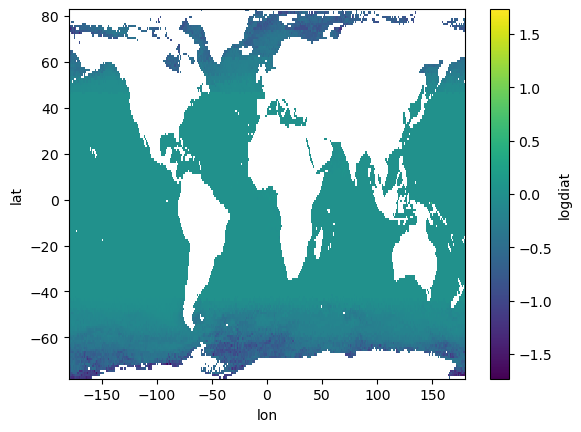

In [48]:
(dcm_fillone['logdiat'] - dcm_fillvar['logdiat']).plot(cmap='viridis')

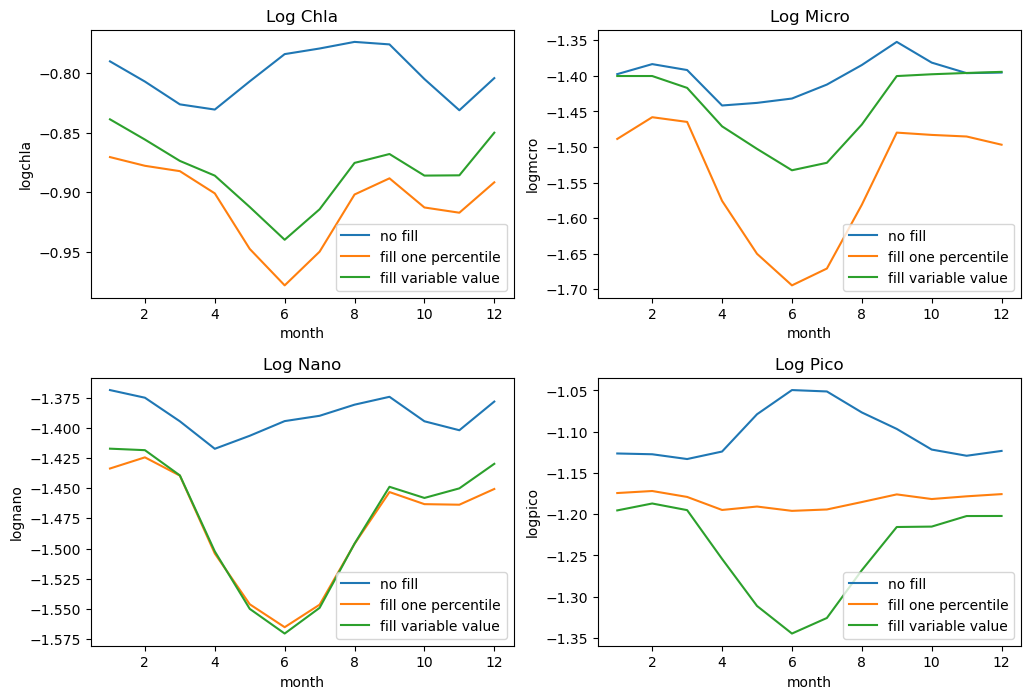

In [49]:
fig, ax = plt.subplots(2,2, figsize=(12,8), dpi=100)
dc_nonfill['logchla'].mean(dim=['lon','lat']).plot.line(ax=ax[0,0], label='no fill')
dc_fillone['logchla'].mean(dim=['lon','lat']).plot.line(ax=ax[0,0],label='fill one percentile')
dc_fillvar['logchla'].mean(dim=['lon','lat']).plot.line(ax=ax[0,0],label='fill variable value')

dc_nonfill['logmcro'].mean(dim=['lon','lat']).plot.line(ax=ax[0,1], label='no fill')
dc_fillone['logmcro'].mean(dim=['lon','lat']).plot.line(ax=ax[0,1],label='fill one percentile')
dc_fillvar['logmcro'].mean(dim=['lon','lat']).plot.line(ax=ax[0,1],label='fill variable value')

dc_nonfill['lognano'].mean(dim=['lon','lat']).plot.line(ax=ax[1,0], label='no fill')
dc_fillone['lognano'].mean(dim=['lon','lat']).plot.line(ax=ax[1,0],label='fill one percentile')
dc_fillvar['lognano'].mean(dim=['lon','lat']).plot.line(ax=ax[1,0],label='fill variable value')

dc_nonfill['logpico'].mean(dim=['lon','lat']).plot.line(ax=ax[1,1], label='no fill')
dc_fillone['logpico'].mean(dim=['lon','lat']).plot.line(ax=ax[1,1],label='fill one percentile')
dc_fillvar['logpico'].mean(dim=['lon','lat']).plot.line(ax=ax[1,1],label='fill variable value')

ax[0,0].set_title("Log Chla")
ax[0,1].set_title("Log Micro")
ax[1,0].set_title("Log Nano")
ax[1,1].set_title("Log Pico")

ax[0,0].legend()
ax[0,1].legend()
ax[1,0].legend()
ax[1,1].legend()

plt.subplots_adjust(hspace=0.3)
plt.show()

In [50]:
def plot_lonmean(var, ds_nonfill, ds_fillone, ds_fillvar):
    fig, ax = plt.subplots(1,3, figsize=(18,4), sharey=True)

    ds_nonfill[var].T.mean(dim='lon').plot(ax=ax[0],  cmap='viridis')
    ds_fillone[var].mean(dim='lon').plot(ax=ax[1], cmap='viridis')
    ds_fillvar[var].mean(dim='lon').plot(ax=ax[2], cmap='viridis')
    ax[0].set_title(f"{var} - no fill")
    ax[1].set_title(f"{var} - one percentile fill")
    ax[2].set_title(f"{var} - variable fill")
    # Adjust the distance between the subplots
    plt.subplots_adjust(wspace=0.5)
    plt.show()

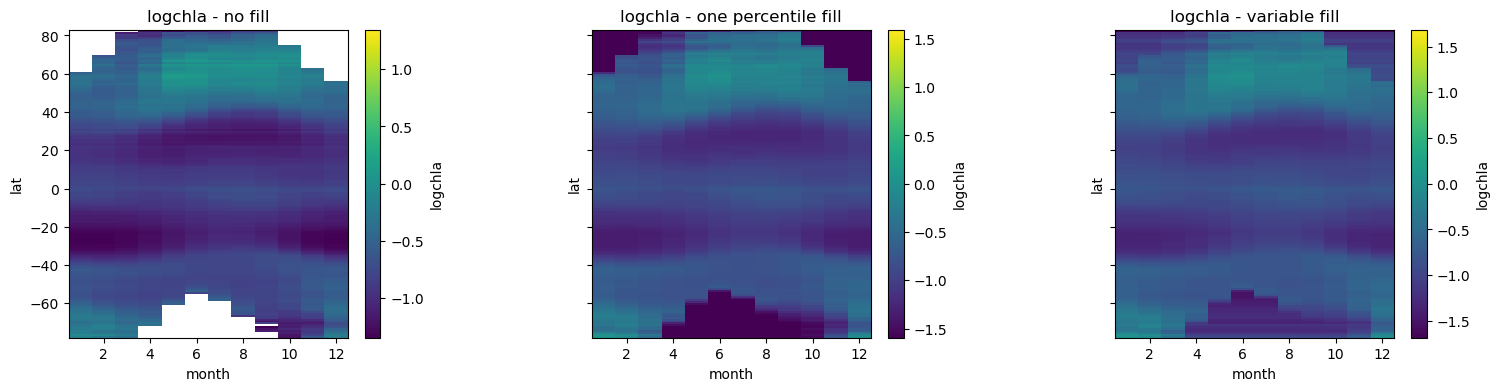

In [51]:
plot_lonmean('logchla', dc_nonfill, dc_fillone, dc_fillvar)

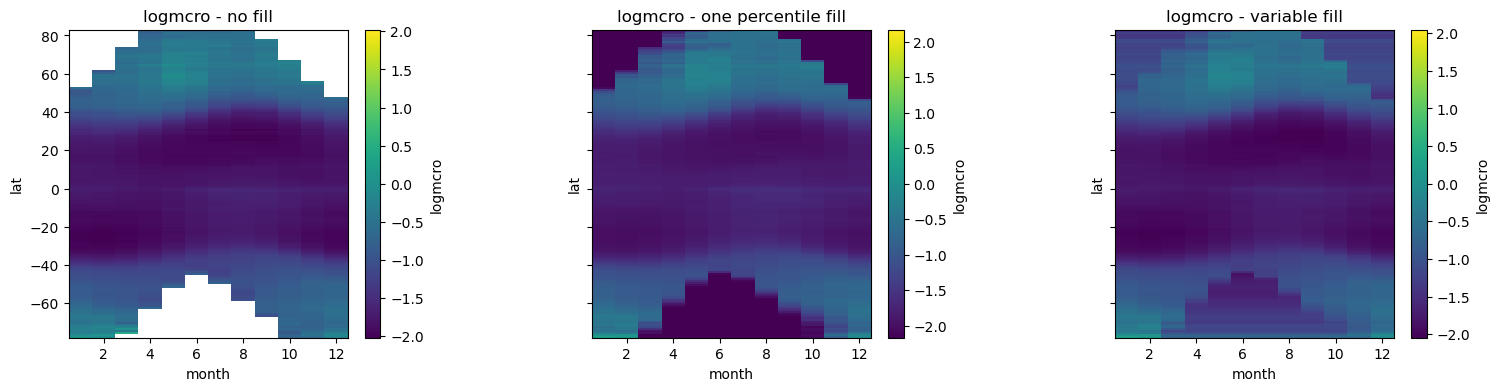

In [52]:
plot_lonmean('logmcro', dc_nonfill, dc_fillone, dc_fillvar)

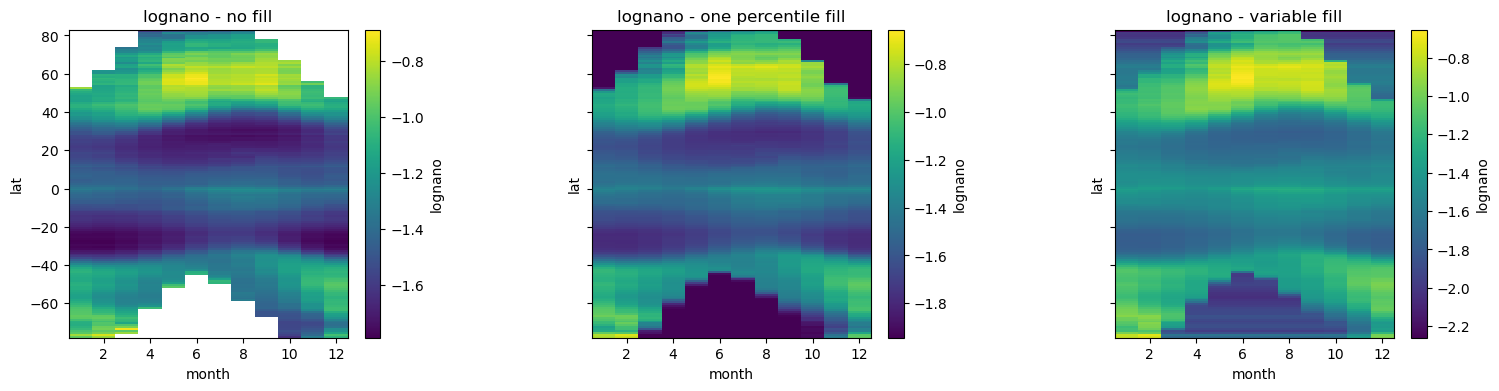

In [53]:
plot_lonmean('lognano', dc_nonfill, dc_fillone, dc_fillvar)

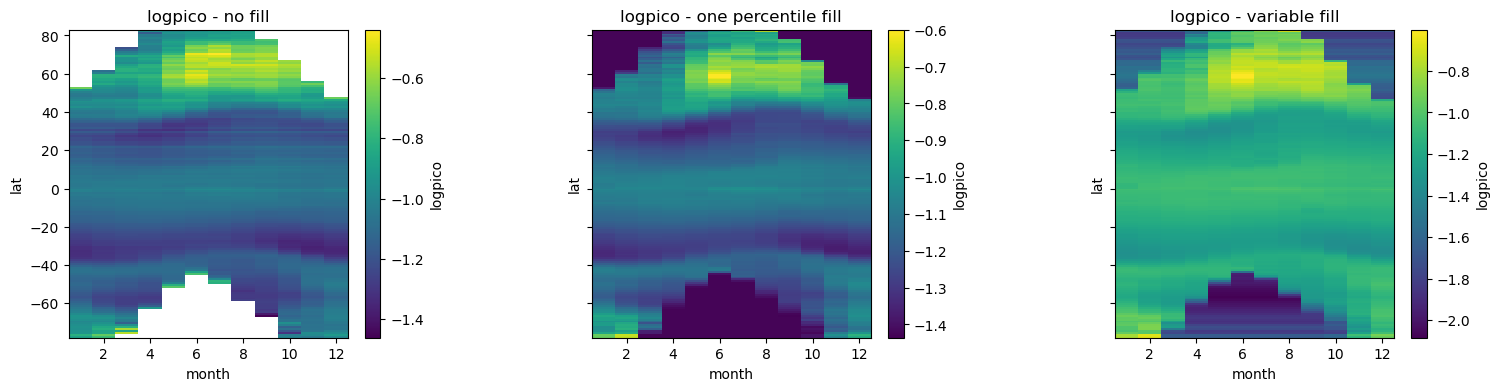

In [54]:
plot_lonmean('logpico', dc_nonfill, dc_fillone, dc_fillvar)

### MODIS Data Wrangling

In [55]:
md = xr.open_dataset(filepath + "modis/AQUA_MODIS.clim.2002_2023.L3m.MC.CHL.x_chlor_a.nc", engine="netcdf4")

In [56]:
md

<xarray.Dataset> Size: 6MB
Dimensions:  (month: 12, lon: 360, lat: 180)
Coordinates:
  * month    (month) datetime64[ns] 96B 1900-01-01 1900-02-01 ... 1900-12-01
  * lon      (lon) float64 3kB -179.5 -178.5 -177.5 -176.5 ... 177.5 178.5 179.5
  * lat      (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
Data variables:
    chlor_a  (month, lat, lon) float64 6MB ...
Attributes: (12/61)
    product_name:                     AQUA_MODIS.20030101_20230131.L3m.MC.CHL...
    instrument:                       MODIS
    title:                            MODISA Level-3 Equidistant Cylindrical ...
    project:                          Ocean Biology Processing Group (NASA/GS...
    platform:                         Aqua
    source:                           satellite observations from MODIS-Aqua
    ...                               ...
    processing_level:                 L3 Mapped
    cdm_data_type:                    grid
    proj4_string:                     +proj=eqc +lat_ts=0 +lat_0=0 +x_0=0 +y_...
    data_bins:                        19888435
    data_minimum:                     0.0014475911
    data_maximum:                     86.29768

In [57]:
md['chlor_a'].attrs

{'long_name': 'Chlorophyll Concentration, OCI Algorithm',
 'units': 'mg m^-3',
 'standard_name': 'mass_concentration_of_chlorophyll_in_sea_water',
 'valid_min': 0.001,
 'valid_max': 100.0,
 'reference': 'Hu, C., Lee Z., and Franz, B.A. (2012). Chlorophyll-a algorithms for oligotrophic oceans: A novel approach based on three-band reflectance difference, J. Geophys. Res., 117, C01011, doi:10.1029/2011JC007395.',
 'display_scale': 'log',
 'display_min': 0.01,
 'display_max': 20.0}

In [58]:
md = md.assign_coords({'month':md.month.dt.month})

In [59]:
md

<xarray.Dataset> Size: 6MB
Dimensions:  (lon: 360, lat: 180, month: 12)
Coordinates:
  * lon      (lon) float64 3kB -179.5 -178.5 -177.5 -176.5 ... 177.5 178.5 179.5
  * lat      (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * month    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
Data variables:
    chlor_a  (month, lat, lon) float64 6MB ...
Attributes: (12/61)
    product_name:                     AQUA_MODIS.20030101_20230131.L3m.MC.CHL...
    instrument:                       MODIS
    title:                            MODISA Level-3 Equidistant Cylindrical ...
    project:                          Ocean Biology Processing Group (NASA/GS...
    platform:                         Aqua
    source:                           satellite observations from MODIS-Aqua
    ...                               ...
    processing_level:                 L3 Mapped
    cdm_data_type:                    grid
    proj4_string:                     +proj=eqc +lat_ts=0 +lat_0=0 +x_0=0 +y_...
    data_bins:                        19888435
    data_minimum:                     0.0014475911
    data_maximum:                     86.29768

In [60]:
md = md.rename({'chlor_a':'chla'})
md

<xarray.Dataset> Size: 6MB
Dimensions:  (lon: 360, lat: 180, month: 12)
Coordinates:
  * lon      (lon) float64 3kB -179.5 -178.5 -177.5 -176.5 ... 177.5 178.5 179.5
  * lat      (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * month    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
Data variables:
    chla     (month, lat, lon) float64 6MB ...
Attributes: (12/61)
    product_name:                     AQUA_MODIS.20030101_20230131.L3m.MC.CHL...
    instrument:                       MODIS
    title:                            MODISA Level-3 Equidistant Cylindrical ...
    project:                          Ocean Biology Processing Group (NASA/GS...
    platform:                         Aqua
    source:                           satellite observations from MODIS-Aqua
    ...                               ...
    processing_level:                 L3 Mapped
    cdm_data_type:                    grid
    proj4_string:                     +proj=eqc +lat_ts=0 +lat_0=0 +x_0=0 +y_...
    data_bins:                        19888435
    data_minimum:                     0.0014475911
    data_maximum:                     86.29768

In [61]:
dm = xr.merge([dsin, md], join='inner')

In [62]:
dm

<xarray.Dataset> Size: 62MB
Dimensions:  (lat: 162, month: 12, lon: 360)
Coordinates:
  * lat      (lat) float64 1kB -77.5 -76.5 -75.5 -74.5 ... 80.5 81.5 82.5 83.5
  * month    (month) uint64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * lon      (lon) float64 3kB -179.5 -178.5 -177.5 -176.5 ... 177.5 178.5 179.5
Data variables:
    dfe      (lon, lat, month) float64 6MB nan nan nan nan ... nan nan nan nan
    mld      (lon, lat, month) float64 6MB nan nan nan nan ... nan nan nan nan
    nh4      (lon, lat, month) float64 6MB nan nan nan nan ... nan nan nan nan
    no3      (lon, lat, month) float64 6MB nan nan nan nan ... nan nan nan nan
    po4      (lon, lat, month) float64 6MB nan nan nan nan ... nan nan nan nan
    rsn      (lon, lat, month) float64 6MB nan nan nan nan ... nan nan nan nan
    sst      (lon, lat, month) float64 6MB nan nan nan nan ... nan nan nan nan
    sal      (lon, lat, month) float64 6MB nan nan nan nan ... nan nan nan nan
    w50      (lon, lat, month) float64 6MB nan nan nan nan ... nan nan nan nan
    sil      (lon, lat, month) float64 6MB nan nan nan nan ... nan nan nan nan
    chla     (month, lat, lon) float64 6MB ...

In [63]:
dm['logchla'] = np.log10(dm['chla'])

In [64]:
# Fractions of PSCs in accordance with Hirata formulas
mcro_frac = ((0.9117 + np.exp((-2.7330 * dm['logchla'].to_numpy()) + 0.4003))**(-1))
pico_frac = (-(0.1529 + np.exp((1.0306 * dm['logchla'].to_numpy()) - 1.5576))**(-1) - 1.8597 * dm['logchla'].to_numpy() + 2.9954)
nano_frac = 1 - mcro_frac - pico_frac

In [65]:
mcro_frac = np.clip(mcro_frac, 0.01, 0.99)
nano_frac = np.clip(nano_frac, 0.01, 0.99)
pico_frac = np.clip(pico_frac, 0.01, 0.99)

In [66]:
dm['mcro'] = mcro_frac * dm['chla']
dm['nano'] = nano_frac * dm['chla']
dm['pico'] = pico_frac * dm['chla']

#### MODIS - No Fill

In [67]:
dm0 = dm.copy()

In [68]:
dm0['logmcro'] = np.log10(dm0['mcro'])
dm0['lognano'] = np.log10(dm0['nano'])
dm0['logpico'] = np.log10(dm0['pico'])

In [69]:
dfm0 = dm0.to_dataframe()
dfm0 = dfm0.astype("float32")
dfm_nonfill = dfm0.dropna()
dfm_nonfill.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 373081 entries, (-77.5, 1, -178.5) to (83.5, 8, -22.5)
Data columns (total 18 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   dfe      373081 non-null  float32
 1   mld      373081 non-null  float32
 2   nh4      373081 non-null  float32
 3   no3      373081 non-null  float32
 4   po4      373081 non-null  float32
 5   rsn      373081 non-null  float32
 6   sst      373081 non-null  float32
 7   sal      373081 non-null  float32
 8   w50      373081 non-null  float32
 9   sil      373081 non-null  float32
 10  chla     373081 non-null  float32
 11  logchla  373081 non-null  float32
 12  mcro     373081 non-null  float32
 13  nano     373081 non-null  float32
 14  pico     373081 non-null  float32
 15  logmcro  373081 non-null  float32
 16  lognano  373081 non-null  float32
 17  logpico  373081 non-null  float32
dtypes: float32(18)
memory usage: 27.4 MB


In [70]:
dm_nonfill = dfm_nonfill.to_xarray()

In [71]:
# dm_nonfill.to_netcdf(filepath + "modis/2002_2023_modis_no_fill.nc")

In [72]:
dmm_nonfill = dm_nonfill.mean(dim='month')

#### MODIS - Fill One percentile

In [73]:
dm1 = dm.copy()

In [74]:
vars = ['chla','mcro','nano','pico']
fill={}
for var in vars:
    fill[f'{var}_fill'] = dm1[var].quantile(0.01, dim=None).values

fill

{'chla_fill': array(0.01811566),
 'mcro_fill': array(0.00018116),
 'nano_fill': array(0.00148214),
 'pico_fill': array(0.01653015)}

In [75]:
for var in vars:
    dm1[var] = dm1[var].fillna(fill[f'{var}_fill'])

In [76]:
dm1['logchla'] = dm1['logchla'].fillna(np.log10(dm1['chla']))
dm1['logmcro'] = np.log10(dm1['mcro'])
dm1['lognano'] = np.log10(dm1['nano'])
dm1['logpico'] = np.log10(dm1['pico'])

In [77]:
dfm = dm1.to_dataframe()
dfm = dfm.astype('float32')
dfm_fillone = dfm.dropna()
dfm_fillone.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 431112 entries, (-77.5, 1, -178.5) to (83.5, 12, -22.5)
Data columns (total 18 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   dfe      431112 non-null  float32
 1   mld      431112 non-null  float32
 2   nh4      431112 non-null  float32
 3   no3      431112 non-null  float32
 4   po4      431112 non-null  float32
 5   rsn      431112 non-null  float32
 6   sst      431112 non-null  float32
 7   sal      431112 non-null  float32
 8   w50      431112 non-null  float32
 9   sil      431112 non-null  float32
 10  chla     431112 non-null  float32
 11  logchla  431112 non-null  float32
 12  mcro     431112 non-null  float32
 13  nano     431112 non-null  float32
 14  pico     431112 non-null  float32
 15  logmcro  431112 non-null  float32
 16  lognano  431112 non-null  float32
 17  logpico  431112 non-null  float32
dtypes: float32(18)
memory usage: 31.7 MB


In [78]:
dm_fillone = dfm_fillone.to_xarray()

In [79]:
# dm_fillone.to_netcdf(filepath + "modis/2002_2023_modis_one-percentile_fill.nc")

In [80]:
dmm_fillone = dm_fillone.mean(dim='month')

#### MODIS - Variable Fill (lower of the min value and 10% of max value at each lat/lon)

In [81]:
dm2 = dm.copy()

In [82]:
# List of variables to process
vars = ['chla','mcro','nano','pico']

for var in vars:
    # Get min and max over 'month' at each (lat, lon)
    min_val = dm2[var].min(dim='month', skipna=True)
    max_val = dm2[var].max(dim='month', skipna=True)
    # print(min_val.shape, max_val.shape)
    
    # Compute 10% of max
    max10 = 0.1 * max_val

    # Take the minimum of (min_val, 10% of max_val)
    fill_val = xr.where(min_val < max10, min_val, max10)
    # print(fill_val.shape)

    # Expand back to (month, lat, lon)
    fill_val_broadcast = fill_val.expand_dims(month=dm2.month).transpose('month', 'lat', 'lon')

    # Replace NaNs with this value
    dm2[var] = dm2[var].fillna(fill_val_broadcast)

In [83]:
dm2['logchla'] = dm2['logchla'].fillna(np.log10(dm2['chla']))
dm2['logmcro'] = np.log10(dm2['mcro'])
dm2['lognano'] = np.log10(dm2['nano'])
dm2['logpico'] = np.log10(dm2['pico'])

In [84]:
dfm = dm2.to_dataframe()
dfm = dfm.astype('float32')
dfm_fillvar = dfm.dropna()
dfm_fillvar.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 430380 entries, (-77.5, 1, -178.5) to (83.5, 12, -22.5)
Data columns (total 18 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   dfe      430380 non-null  float32
 1   mld      430380 non-null  float32
 2   nh4      430380 non-null  float32
 3   no3      430380 non-null  float32
 4   po4      430380 non-null  float32
 5   rsn      430380 non-null  float32
 6   sst      430380 non-null  float32
 7   sal      430380 non-null  float32
 8   w50      430380 non-null  float32
 9   sil      430380 non-null  float32
 10  chla     430380 non-null  float32
 11  logchla  430380 non-null  float32
 12  mcro     430380 non-null  float32
 13  nano     430380 non-null  float32
 14  pico     430380 non-null  float32
 15  logmcro  430380 non-null  float32
 16  lognano  430380 non-null  float32
 17  logpico  430380 non-null  float32
dtypes: float32(18)
memory usage: 31.6 MB


In [85]:
dm_fillvar = dfm_fillvar.to_xarray()

In [86]:
# dm_fillvar.to_netcdf(filepath + "modis/2002_2023_modis_variable_fill.nc")

In [87]:
dmm_fillvar = dm_fillvar.mean(dim='month')

#### MODIS - Comparison

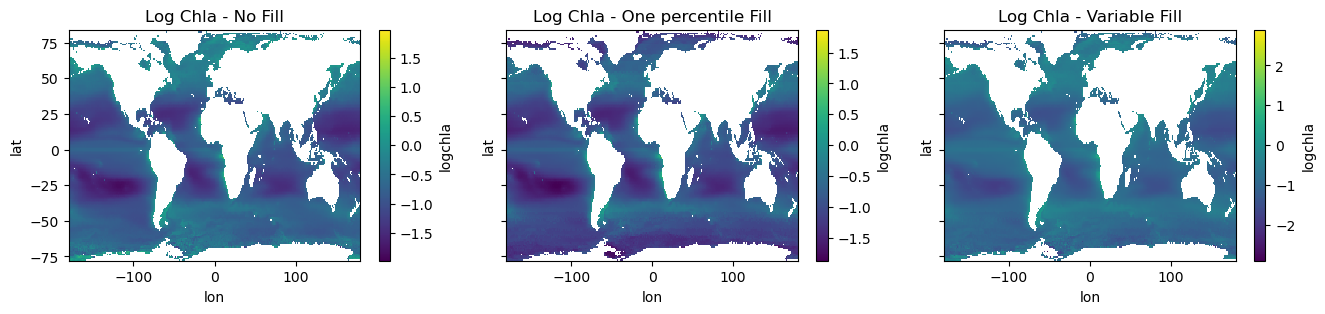

In [88]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16,3), sharey=True, dpi=100)
dmm_nonfill['logchla'].plot(ax=ax1, cmap='viridis')
dmm_fillone['logchla'].plot(ax=ax2, cmap='viridis')
dmm_fillvar['logchla'].plot(ax=ax3, cmap='viridis')
ax1.set_title("Log Chla - No Fill")
ax2.set_title("Log Chla - One percentile Fill")
ax3.set_title("Log Chla - Variable Fill")
plt.show()

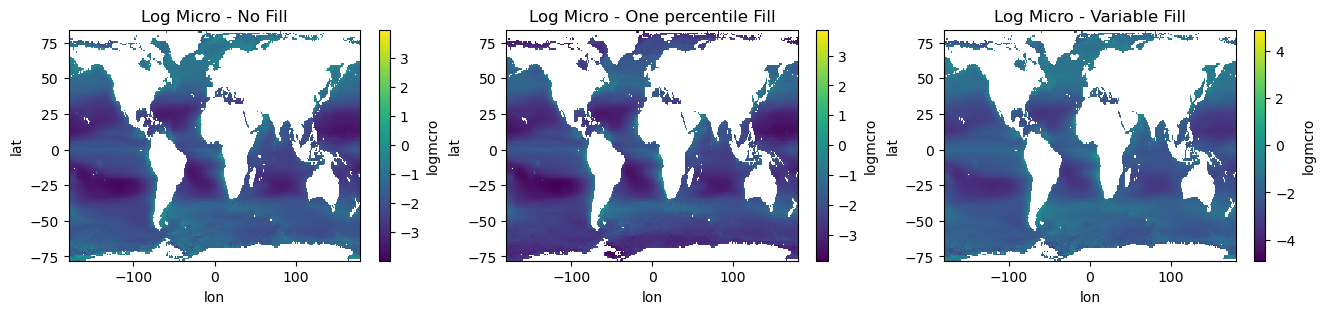

In [89]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16,3), dpi=100)
dmm_nonfill['logmcro'].plot(ax=ax1, cmap='viridis')
dmm_fillone['logmcro'].plot(ax=ax2, cmap='viridis')
dmm_fillvar['logmcro'].plot(ax=ax3, cmap='viridis')
ax1.set_title("Log Micro - No Fill")
ax2.set_title("Log Micro - One percentile Fill")
ax3.set_title("Log Micro - Variable Fill")
plt.show()

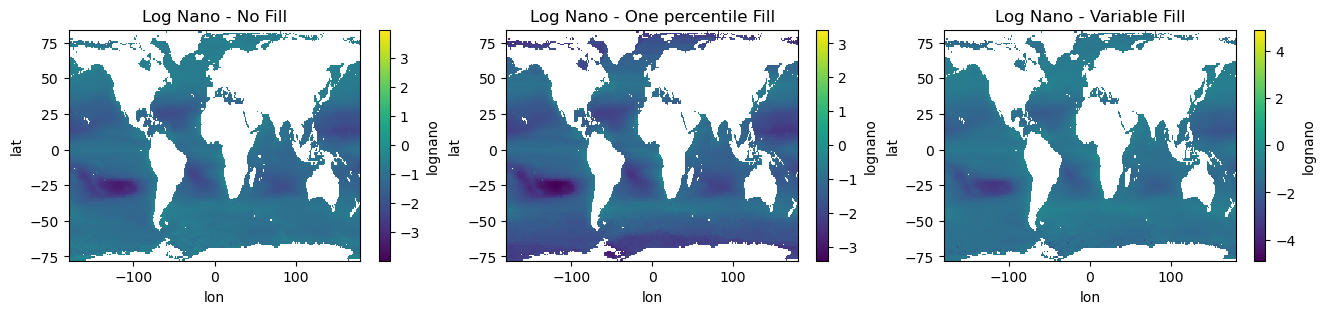

In [90]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16,3), dpi=100)
dmm_nonfill['lognano'].plot(ax=ax1, cmap='viridis')
dmm_fillone['lognano'].plot(ax=ax2, cmap='viridis')
dmm_fillvar['lognano'].plot(ax=ax3, cmap='viridis')
ax1.set_title("Log Nano - No Fill")
ax2.set_title("Log Nano - One percentile Fill")
ax3.set_title("Log Nano - Variable Fill")
plt.show()

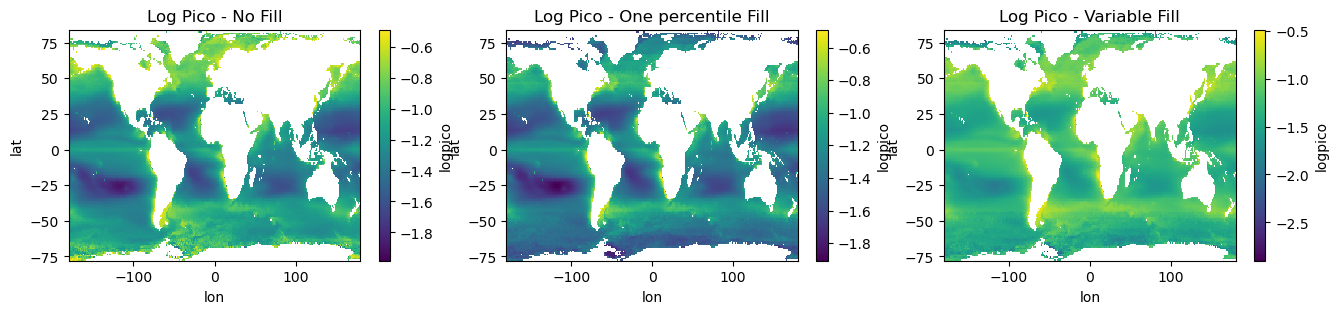

In [91]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16,3), dpi=100)
dmm_nonfill['logpico'].plot(ax=ax1, cmap='viridis')
dmm_fillone['logpico'].plot(ax=ax2, cmap='viridis')
dmm_fillvar['logpico'].plot(ax=ax3, cmap='viridis')
ax1.set_title("Log Pico - No Fill")
ax2.set_title("Log Pico - One percentile Fill")
ax3.set_title("Log Pico - Variable Fill")
plt.show()

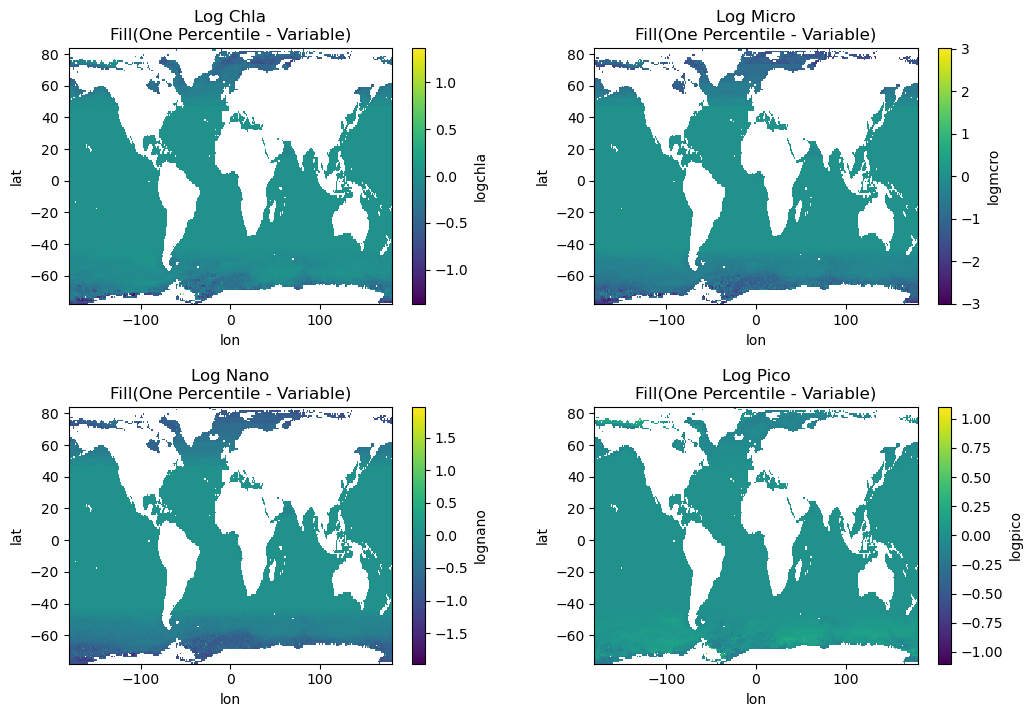

In [92]:
fig, ax = plt.subplots(2,2, figsize=(12,8), dpi=100)

(dmm_fillone['logchla'] - dmm_fillvar['logchla']).plot(ax=ax[0,0], cmap='viridis')
(dmm_fillone['logmcro'] - dmm_fillvar['logmcro']).plot(ax=ax[0,1], cmap='viridis')
(dmm_fillone['lognano'] - dmm_fillvar['lognano']).plot(ax=ax[1,0], cmap='viridis')
(dmm_fillone['logpico'] - dmm_fillvar['logpico']).plot(ax=ax[1,1], cmap='viridis')

ax[0,0].set_title("Log Chla\nFill(One Percentile - Variable)")
ax[0,1].set_title("Log Micro\nFill(One Percentile - Variable)")
ax[1,0].set_title("Log Nano\nFill(One Percentile - Variable)")
ax[1,1].set_title("Log Pico\nFill(One Percentile - Variable)")
plt.subplots_adjust(wspace=0.3, hspace=0.4)
plt.show()

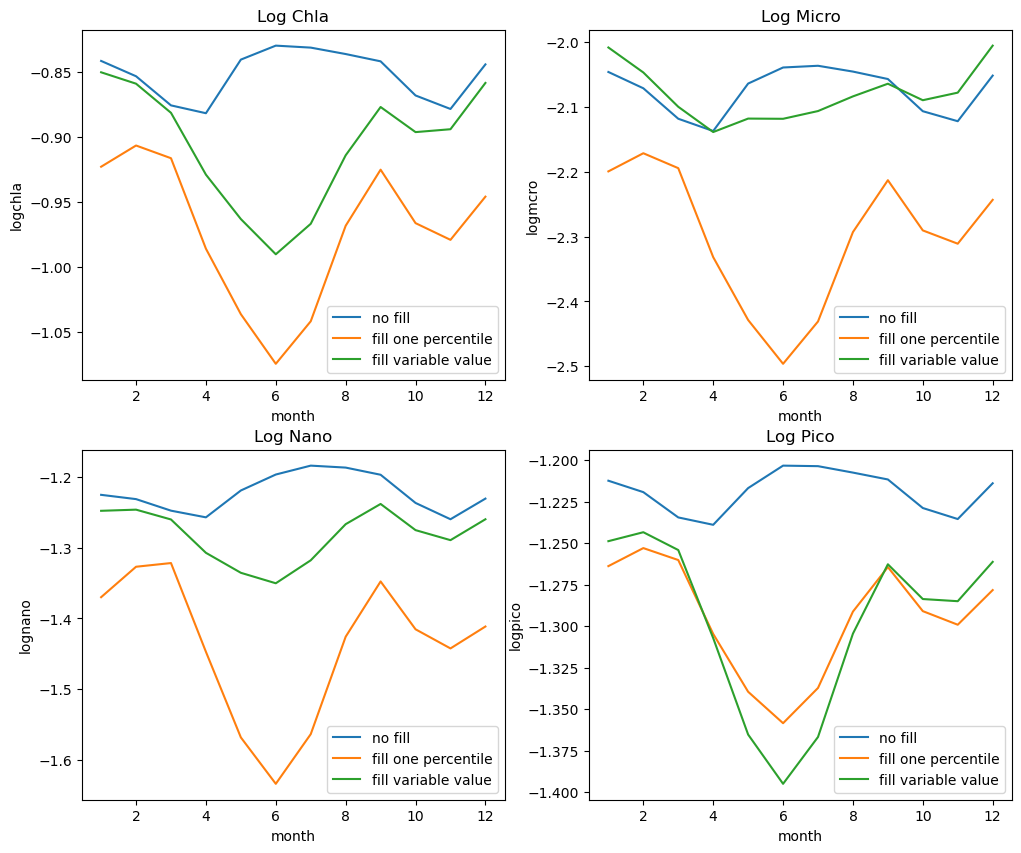

In [93]:
fig, ax = plt.subplots(2, 2, figsize=(12, 10), dpi=100)

dm_nonfill['logchla'].mean(['lon','lat']).plot.line(ax=ax[0,0], label='no fill')
dm_fillone['logchla'].mean(['lon','lat']).plot.line(ax=ax[0,0], label='fill one percentile')
dm_fillvar['logchla'].mean(['lon','lat']).plot.line(ax=ax[0,0], label='fill variable value')

dm_nonfill['logmcro'].mean(['lon','lat']).plot.line(ax=ax[0,1], label='no fill')
dm_fillone['logmcro'].mean(['lon','lat']).plot.line(ax=ax[0,1], label='fill one percentile')
dm_fillvar['logmcro'].mean(['lon','lat']).plot.line(ax=ax[0,1], label='fill variable value')

dm_nonfill['lognano'].mean(['lon','lat']).plot.line(ax=ax[1,0], label='no fill')
dm_fillone['lognano'].mean(['lon','lat']).plot.line(ax=ax[1,0], label='fill one percentile')
dm_fillvar['lognano'].mean(['lon','lat']).plot.line(ax=ax[1,0], label='fill variable value')

dm_nonfill['logpico'].mean(['lon','lat']).plot.line(ax=ax[1,1], label='no fill')
dm_fillone['logpico'].mean(['lon','lat']).plot.line(ax=ax[1,1], label='fill one percentile')
dm_fillvar['logpico'].mean(['lon','lat']).plot.line(ax=ax[1,1], label='fill variable value')

ax[0,0].set_title("Log Chla")
ax[0,1].set_title("Log Micro")
ax[1,0].set_title("Log Nano")
ax[1,1].set_title("Log Pico")

ax[0,0].legend()
ax[0,1].legend()
ax[1,0].legend()
ax[1,1].legend()
plt.show()

In [94]:
def plot_lonmean(var, ds_nonfill, ds_fillone, ds_fillvar):
    fig, ax = plt.subplots(1,3, figsize=(18,4), sharey=True)
    ds_nonfill[var].mean(dim='lon').plot(ax=ax[0], cmap='viridis')
    ds_fillone[var].mean(dim='lon').plot(ax=ax[1], cmap='viridis')
    ds_fillvar[var].mean(dim='lon').plot(ax=ax[2], cmap='viridis')
    ax[0].set_title(f"{var} - no fill")
    ax[0].set_title(f"{var} - one percentile fill")
    ax[1].set_title(f"{var} - variable fill")
    # Adjust the distance between the subplots
    plt.subplots_adjust(wspace=0.5)
    plt.show()

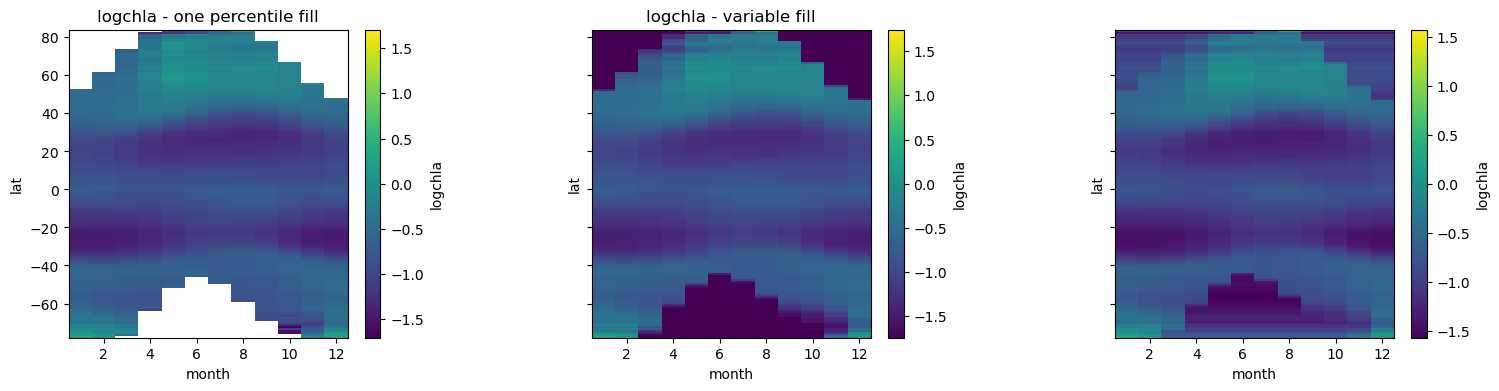

In [95]:
plot_lonmean('logchla', dm_nonfill, dm_fillone, dm_fillvar)

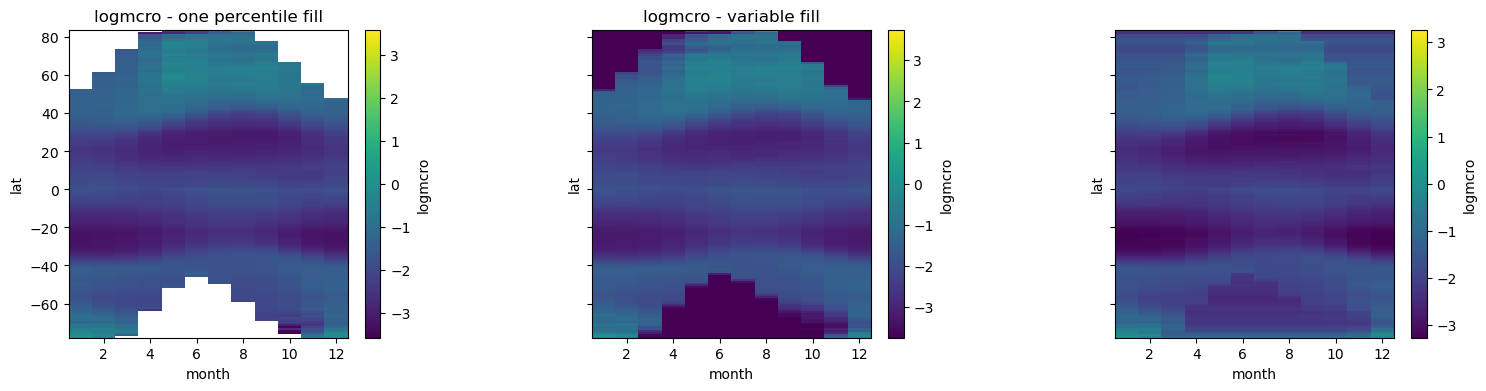

In [96]:
plot_lonmean('logmcro', dm_nonfill, dm_fillone, dm_fillvar)

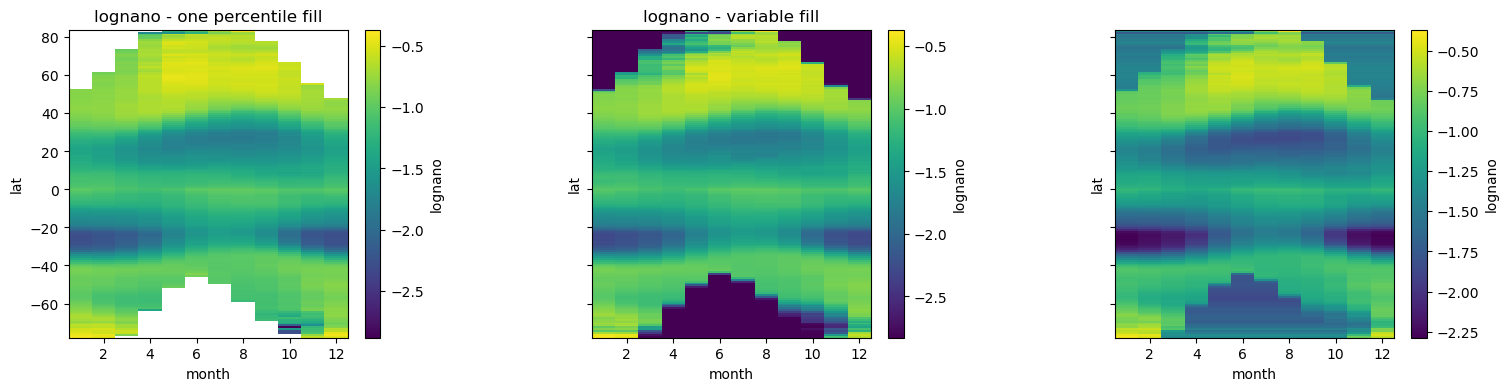

In [97]:
plot_lonmean('lognano', dm_nonfill, dm_fillone, dm_fillvar)

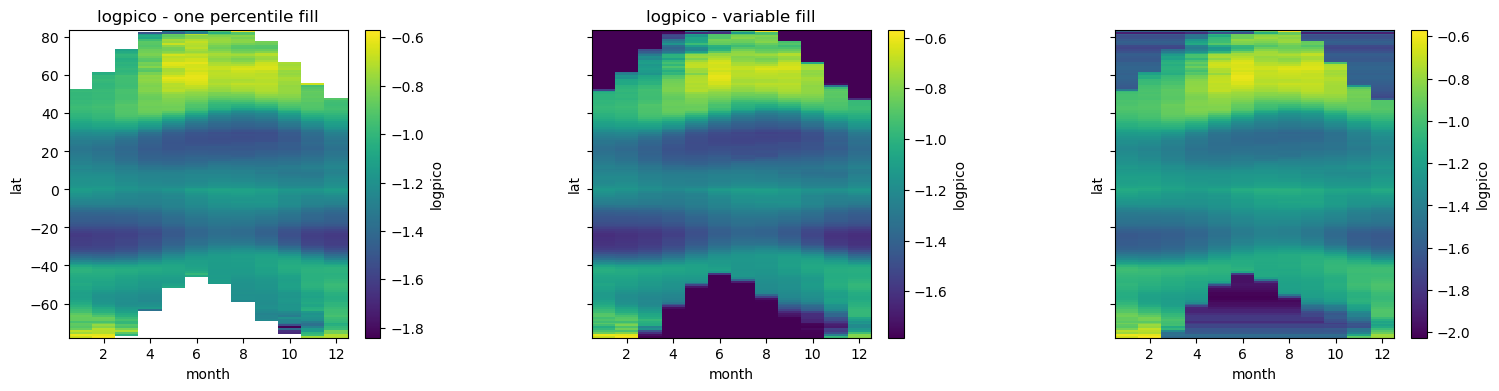

In [98]:
plot_lonmean('logpico', dm_nonfill, dm_fillone, dm_fillvar)

### Kostadinov Data Wrangling

To convert phytoplankton carbon concentration from milligrams per cubic meter (mg/m³) to moles per cubic meter (mol/m³), use the molar mass of carbon.
The molar mass of carbon (C) is approximately 12.01 grams per mole (g/mol). Since there are 1000 milligrams in a gram, to convert from mg/m³ to g/m³, you divide the value in mg/m³ by 1000.

$1 moles/m^3 = 12.01g/m^3 = 12010 mg/m^3$  
$1 mg/m^3 = \frac{1}{1.2e4} moles/m^3$

In [99]:
# data['phyc'] = (10**data["logphyc"])/1.2e4 # convert from mg/m-3 to moles/m-3
data['logphyc'] = data['logphyc'] + np.log10(12010) # convert from moles/m3 to mg/m3

In [100]:
data['phyc'] = (10**data["logphyc"])

In [101]:
print("Phyc :",data['phyc'].min().values, data['phyc'].max().values)

Phyc : 1.273523669074249 203.60372596169083


In [102]:
# cmicro, cnano, cpico are in mg/m-3
cobs = xr.open_dataset(filepath + "kostadinov/data/kostadinov_coarse2.nc", engine='netcdf4')

In [103]:
cobs

<xarray.Dataset> Size: 19MB
Dimensions:  (lon: 360, lat: 180, month: 12)
Coordinates:
  * lon      (lon) float64 3kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
  * lat      (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * month    (month) float64 96B 1.0 2.0 3.0 4.0 5.0 ... 8.0 9.0 10.0 11.0 12.0
Data variables:
    cmicro   (lon, lat, month) float64 6MB ...
    cnano    (lon, lat, month) float64 6MB ...
    cpico    (lon, lat, month) float64 6MB ...

In [104]:
# convert cmicro, cnano, cpico from moles/ m3 to mg/m3. multiply by 1.2e4
# cobs[['cmicro', 'cnano', 'cpico']] = cobs[['cmicro', 'cnano', 'cpico']] * 12010

In [105]:
data

<xarray.Dataset> Size: 67MB
Dimensions:  (lat: 162, month: 12, lon: 360)
Coordinates:
  * lat      (lat) float64 1kB -77.5 -76.5 -75.5 -74.5 ... 80.5 81.5 82.5 83.5
  * month    (month) uint64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * lon      (lon) float64 3kB -179.5 -178.5 -177.5 -176.5 ... 177.5 178.5 179.5
Data variables:
    dfe      (lon, lat, month) float64 6MB nan nan nan nan ... nan nan nan nan
    mld      (lon, lat, month) float64 6MB nan nan nan nan ... nan nan nan nan
    nh4      (lon, lat, month) float64 6MB nan nan nan nan ... nan nan nan nan
    no3      (lon, lat, month) float64 6MB nan nan nan nan ... nan nan nan nan
    po4      (lon, lat, month) float64 6MB nan nan nan nan ... nan nan nan nan
    rsn      (lon, lat, month) float64 6MB nan nan nan nan ... nan nan nan nan
    sst      (lon, lat, month) float64 6MB nan nan nan nan ... nan nan nan nan
    sal      (lon, lat, month) float64 6MB nan nan nan nan ... nan nan nan nan
    w50      (lon, lat, month) float64 6MB nan nan nan nan ... nan nan nan nan
    sil      (lon, lat, month) float64 6MB nan nan nan nan ... nan nan nan nan
    logphyc  (lon, lat, month) float64 6MB nan nan nan nan ... nan nan nan nan
    phyc     (lon, lat, month) float64 6MB nan nan nan nan ... nan nan nan nan

In [106]:
cobs

<xarray.Dataset> Size: 19MB
Dimensions:  (lon: 360, lat: 180, month: 12)
Coordinates:
  * lon      (lon) float64 3kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
  * lat      (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * month    (month) float64 96B 1.0 2.0 3.0 4.0 5.0 ... 8.0 9.0 10.0 11.0 12.0
Data variables:
    cmicro   (lon, lat, month) float64 6MB ...
    cnano    (lon, lat, month) float64 6MB ...
    cpico    (lon, lat, month) float64 6MB ...

In [107]:
cobs = convert360_180(cobs)

In [108]:
cobs

<xarray.Dataset> Size: 19MB
Dimensions:  (lon: 360, lat: 180, month: 12)
Coordinates:
  * lat      (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * month    (month) float64 96B 1.0 2.0 3.0 4.0 5.0 ... 8.0 9.0 10.0 11.0 12.0
  * lon      (lon) float64 3kB -179.5 -178.5 -177.5 -176.5 ... 177.5 178.5 179.5
Data variables:
    cmicro   (lon, lat, month) float64 6MB ...
    cnano    (lon, lat, month) float64 6MB ...
    cpico    (lon, lat, month) float64 6MB ...

In [109]:
dk = xr.merge([data,cobs], join='inner')

In [110]:
dk

<xarray.Dataset> Size: 84MB
Dimensions:  (lat: 162, month: 12, lon: 360)
Coordinates:
  * lat      (lat) float64 1kB -77.5 -76.5 -75.5 -74.5 ... 80.5 81.5 82.5 83.5
  * month    (month) uint64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * lon      (lon) float64 3kB -179.5 -178.5 -177.5 -176.5 ... 177.5 178.5 179.5
Data variables: (12/15)
    dfe      (lon, lat, month) float64 6MB nan nan nan nan ... nan nan nan nan
    mld      (lon, lat, month) float64 6MB nan nan nan nan ... nan nan nan nan
    nh4      (lon, lat, month) float64 6MB nan nan nan nan ... nan nan nan nan
    no3      (lon, lat, month) float64 6MB nan nan nan nan ... nan nan nan nan
    po4      (lon, lat, month) float64 6MB nan nan nan nan ... nan nan nan nan
    rsn      (lon, lat, month) float64 6MB nan nan nan nan ... nan nan nan nan
    ...       ...
    sil      (lon, lat, month) float64 6MB nan nan nan nan ... nan nan nan nan
    logphyc  (lon, lat, month) float64 6MB nan nan nan nan ... nan nan nan nan
    phyc     (lon, lat, month) float64 6MB nan nan nan nan ... nan nan nan nan
    cmicro   (lon, lat, month) float64 6MB ...
    cnano    (lon, lat, month) float64 6MB ...
    cpico    (lon, lat, month) float64 6MB ...

In [111]:
dk = dk.rename({'cmicro':'mcro','cnano':'nano','cpico':'pico'})

#### Kostadinov - No Fill

In [112]:
dk0 = dk.copy()

In [113]:
dfk0 = dk.to_dataframe()
dfk0 = dfk0.astype("float32")
dfk_nonfill = dfk0.dropna()
dfk_nonfill.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 381975 entries, (-77.5, 1, -178.5) to (83.5, 8, -22.5)
Data columns (total 15 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   dfe      381975 non-null  float32
 1   mld      381975 non-null  float32
 2   nh4      381975 non-null  float32
 3   no3      381975 non-null  float32
 4   po4      381975 non-null  float32
 5   rsn      381975 non-null  float32
 6   sst      381975 non-null  float32
 7   sal      381975 non-null  float32
 8   w50      381975 non-null  float32
 9   sil      381975 non-null  float32
 10  logphyc  381975 non-null  float32
 11  phyc     381975 non-null  float32
 12  mcro     381975 non-null  float32
 13  nano     381975 non-null  float32
 14  pico     381975 non-null  float32
dtypes: float32(15)
memory usage: 23.7 MB


In [114]:
dfk_nonfill['logmcro'] = np.log10(dfk_nonfill['mcro'])
dfk_nonfill['lognano'] = np.log10(dfk_nonfill['nano'])
dfk_nonfill['logpico'] = np.log10(dfk_nonfill['pico'])

In [115]:
dk_nonfill = dfk_nonfill.to_xarray()
dkm_nonfill = dk_nonfill.mean(dim='month')

In [116]:
print(dk_nonfill['phyc'].min().values, dk_nonfill['phyc'].max().values)

1.2735236883163452 203.60372924804688


In [117]:
print(dk_nonfill['mcro'].min().values, dk_nonfill['mcro'].max().values)

0.00015415542293339968 88.00513458251953


In [118]:
print(dk_nonfill['nano'].min().values, dk_nonfill['nano'].max().values)

0.03473378345370293 97.03726959228516


In [119]:
print(dk_nonfill['pico'].min().values, dk_nonfill['pico'].max().values)

0.878749430179596 47.1532096862793


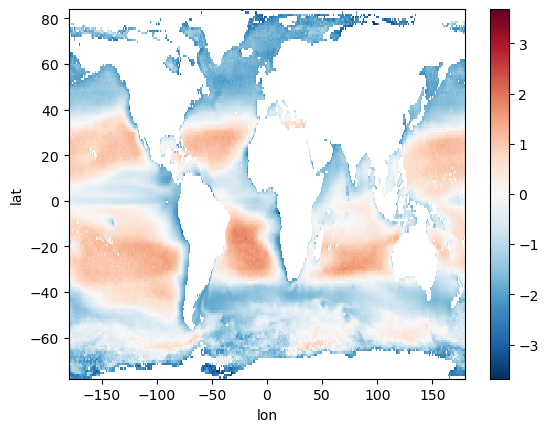

In [120]:
(dkm_nonfill['logphyc'] - (dkm_nonfill['logmcro']+dkm_nonfill['lognano']+dkm_nonfill['logpico'])).plot()

In [121]:
# dk_nonfill.to_netcdf(filepath + "kostadinov/kostadinov_composite_no_fill.nc")

#### Kostadinov - One Percentile Fill

In [122]:
dk1 = dk.copy()

In [123]:
vars = ['phyc','mcro','nano','pico']
fill = {}
for var in vars:
    fill[f'{var}_fill'] = dk1[var].quantile(0.01, dim=None).values

fill

{'phyc_fill': array(4.33916633),
 'mcro_fill': array(0.02553042),
 'nano_fill': array(0.4849079),
 'pico_fill': array(4.0939573)}

In [124]:
for var in vars:
    dk1[var] = dk1[var].fillna(fill[f'{var}_fill'])

In [125]:
dk1['logphyc'] = dk1['logphyc'].fillna(np.log10(dk1['phyc']))
dk1['logmcro'] = np.log10(dk1['mcro'])
dk1['lognano'] = np.log10(dk1['nano'])
dk1['logpico'] = np.log10(dk1['pico'])

In [126]:
dfk1 = dk1.to_dataframe()
dfk1 = dfk1.astype('float32')
dfk_fillone = dfk1.dropna()
dfk_fillone.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 431112 entries, (-77.5, 1, -178.5) to (83.5, 12, -22.5)
Data columns (total 18 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   dfe      431112 non-null  float32
 1   mld      431112 non-null  float32
 2   nh4      431112 non-null  float32
 3   no3      431112 non-null  float32
 4   po4      431112 non-null  float32
 5   rsn      431112 non-null  float32
 6   sst      431112 non-null  float32
 7   sal      431112 non-null  float32
 8   w50      431112 non-null  float32
 9   sil      431112 non-null  float32
 10  logphyc  431112 non-null  float32
 11  phyc     431112 non-null  float32
 12  mcro     431112 non-null  float32
 13  nano     431112 non-null  float32
 14  pico     431112 non-null  float32
 15  logmcro  431112 non-null  float32
 16  lognano  431112 non-null  float32
 17  logpico  431112 non-null  float32
dtypes: float32(18)
memory usage: 31.7 MB


In [127]:
dk_fillone = dfk_fillone.to_xarray()

In [128]:
# dk_fillone.to_netcdf(filepath + "kostadinov/kostadinov_composite_one-percentile_fill.nc")

In [129]:
dkm_fillone = dk_fillone.mean(dim='month')

#### Kostadinov - Variable Fill

In [130]:
dk2 = dk.copy()

In [131]:
vars = ['phyc','mcro','nano','pico']
for var in vars:
    min_val = dk2[var].min(dim='month', skipna=True)
    max_val = dk2[var].max(dim='month', skipna=True)
    max10   = 0.1 * max_val
    fill_val = xr.where(min_val < max10, min_val, max10)
    fill_val_broadcast = fill_val.expand_dims(month=dk2.month).transpose('month','lat','lon')
    dk2[var] = dk2[var].fillna(fill_val_broadcast)

In [132]:
dk2['logphyc'] = dk2['logphyc'].fillna(np.log10(dk2['phyc']))
dk2['logmcro'] = np.log10(dk2['mcro'])
dk2['lognano'] = np.log10(dk2['nano'])
dk2['logpico'] = np.log10(dk2['pico'])

In [133]:
dfk2 = dk2.to_dataframe()
dfk2 = dfk2.astype('float32')
dfk_fillvar = dfk2.dropna()
dfk_fillvar.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 431112 entries, (-77.5, 1, -178.5) to (83.5, 12, -22.5)
Data columns (total 18 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   dfe      431112 non-null  float32
 1   mld      431112 non-null  float32
 2   nh4      431112 non-null  float32
 3   no3      431112 non-null  float32
 4   po4      431112 non-null  float32
 5   rsn      431112 non-null  float32
 6   sst      431112 non-null  float32
 7   sal      431112 non-null  float32
 8   w50      431112 non-null  float32
 9   sil      431112 non-null  float32
 10  logphyc  431112 non-null  float32
 11  phyc     431112 non-null  float32
 12  mcro     431112 non-null  float32
 13  nano     431112 non-null  float32
 14  pico     431112 non-null  float32
 15  logmcro  431112 non-null  float32
 16  lognano  431112 non-null  float32
 17  logpico  431112 non-null  float32
dtypes: float32(18)
memory usage: 31.7 MB


In [134]:
dk_fillvar = dfk_fillvar.to_xarray()

In [135]:
# dk_fillvar.to_netcdf(filepath + "kostadinov/kostadinov_composite_variable_fill.nc")

In [136]:
dkm_fillvar = dk_fillvar.mean(dim='month')

In [137]:
print(dkm_fillvar['logphyc'].min().values, dkm_fillvar['logphyc'].max().values)

0.6563077569007874 2.0824873447418213


In [138]:
print(dkm_fillvar['logmcro'].min().values, dkm_fillvar['logmcro'].max().values)

-3.1519196033477783 1.6917284727096558


In [139]:
print(dkm_fillvar['lognano'].min().values, dkm_fillvar['lognano'].max().values)

-1.0871222019195557 1.7350112199783325


In [140]:
print(dkm_fillvar['logpico'].min().values, dkm_fillvar['logpico'].max().values)

-0.10913794487714767 1.5592485666275024


#### Kostadinov - Comparison

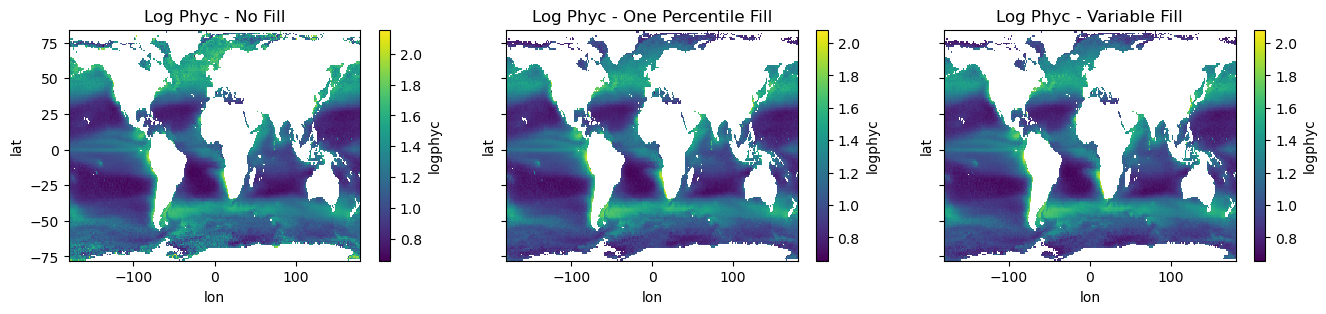

In [141]:
fig, (ax1, ax2, ax3) = plt.subplots(1,3, figsize=(16,3),sharey=True, dpi=100)

dkm_nonfill['logphyc'].plot(ax=ax1, cmap='viridis')
dkm_fillone['logphyc'].plot(ax=ax2, cmap='viridis')
dkm_fillvar['logphyc'].plot(ax=ax3, cmap='viridis')

ax1.set_title("Log Phyc - No Fill")
ax2.set_title("Log Phyc - One Percentile Fill")
ax3.set_title("Log Phyc - Variable Fill")

plt.show()

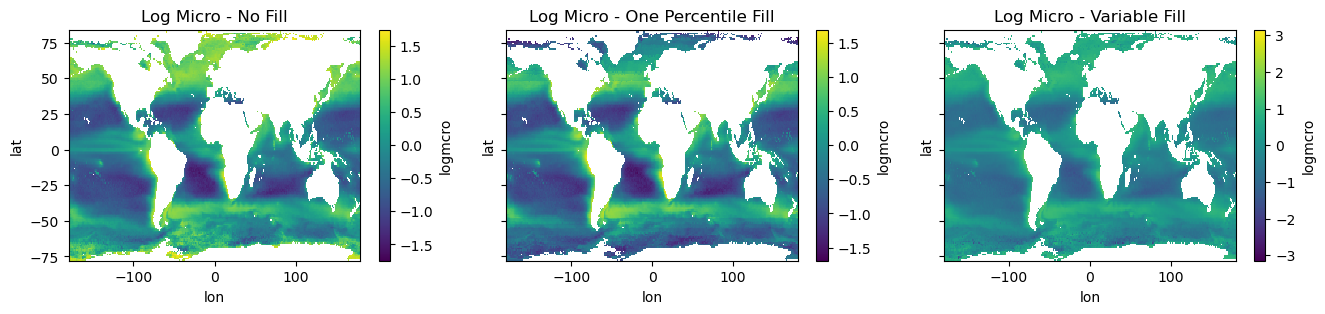

In [142]:
fig, (ax1, ax2, ax3) = plt.subplots(1,3, figsize=(16,3), sharey=True, dpi=100)

dkm_nonfill['logmcro'].plot(ax=ax1, cmap='viridis')
dkm_fillone['logmcro'].plot(ax=ax2, cmap='viridis')
dkm_fillvar['logmcro'].plot(ax=ax3, cmap='viridis')

ax1.set_title("Log Micro - No Fill")
ax2.set_title("Log Micro - One Percentile Fill")
ax3.set_title("Log Micro - Variable Fill")

plt.show()

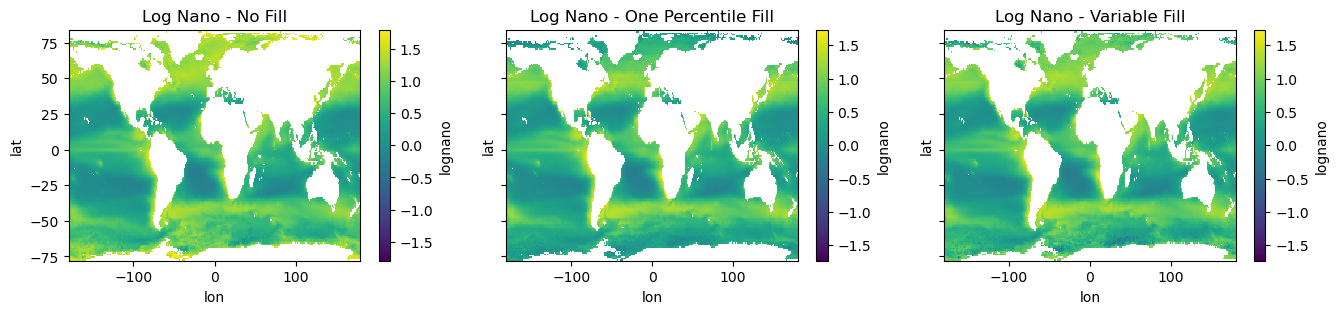

In [143]:
fig, (ax1, ax2, ax3) = plt.subplots(1,3, figsize=(16,3), sharey=True, dpi=100)

dkm_nonfill['lognano'].plot(ax=ax1, cmap='viridis')
dkm_fillone['lognano'].plot(ax=ax2, cmap='viridis')
dkm_fillvar['lognano'].plot(ax=ax3, cmap='viridis')

ax1.set_title("Log Nano - No Fill")
ax2.set_title("Log Nano - One Percentile Fill")
ax3.set_title("Log Nano - Variable Fill")
plt.show()

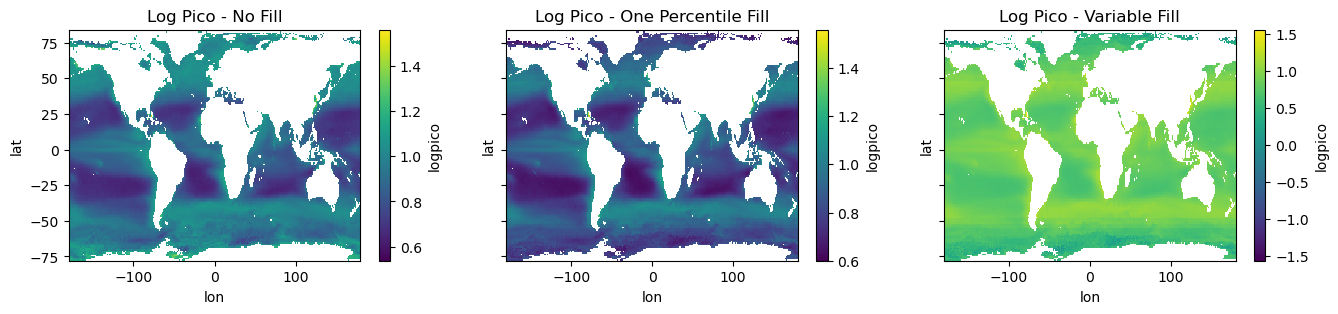

In [144]:
fig, (ax1, ax2, ax3) = plt.subplots(1,3, figsize=(16,3), sharey=True, dpi=100)

dkm_nonfill['logpico'].plot(ax=ax1, cmap='viridis')
dkm_fillone['logpico'].plot(ax=ax2, cmap='viridis')
dkm_fillvar['logpico'].plot(ax=ax3, cmap='viridis')

ax1.set_title("Log Pico - No Fill")
ax2.set_title("Log Pico - One Percentile Fill")
ax3.set_title("Log Pico - Variable Fill")

plt.show()

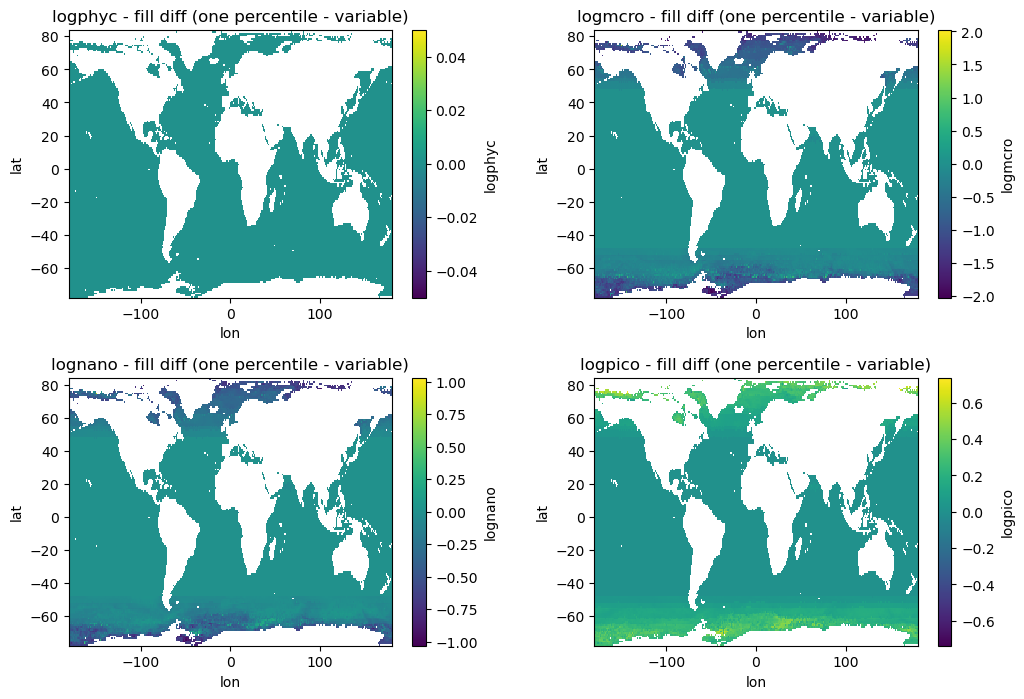

In [145]:
fig, ax = plt.subplots(2, 2, figsize=(12,8), dpi=100)

variables = ['logphyc','logmcro','lognano','logpico']
ax = ax.flatten()
for i, var in enumerate(variables):
    (dkm_fillone[var] - dkm_fillvar[var]).plot(ax=ax[i], cmap='viridis')
    ax[i].set_title(f"{var} - fill diff (one percentile - variable)")
plt.subplots_adjust(wspace=0.3, hspace=0.3)
plt.show()

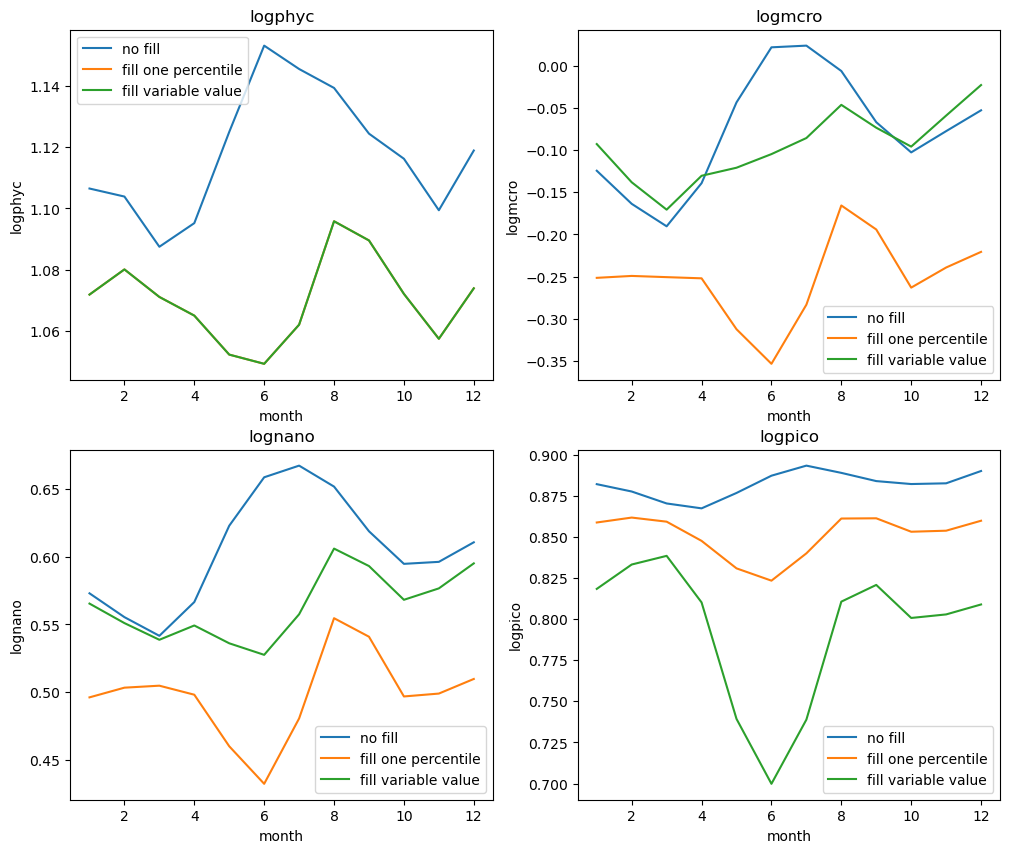

In [146]:
fig, ax = plt.subplots(2, 2, figsize=(12,10), dpi=100)

variables = ['logphyc','logmcro','lognano','logpico']
ax = ax.flatten()
for i, var in enumerate(variables):
    dk_nonfill[var].mean(['lon','lat']).plot(ax=ax[i], label='no fill')
    dk_fillone[var].mean(['lon','lat']).plot(ax=ax[i], label="fill one percentile")
    dk_fillvar[var].mean(['lon','lat']).plot(ax=ax[i], label="fill variable value")
    ax[i].set_title(f"{var}")
    ax[i].legend()
plt.show()  

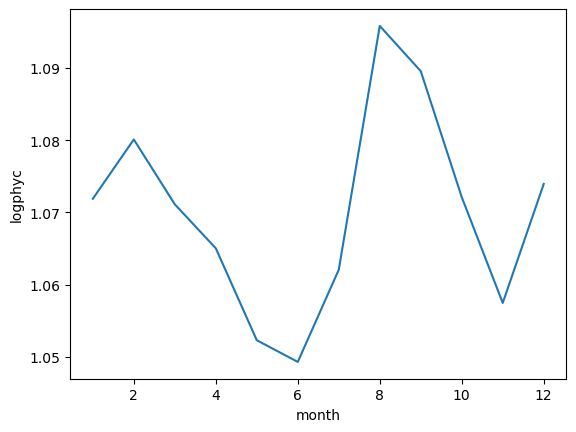

In [147]:
dk_fillone['logphyc'].mean(['lon','lat']).plot()

In [148]:
def plot_lonmean(var, ds_nonfill, ds_fillone, ds_fillvar):
    fig, ax = plt.subplots(1,3, figsize=(18,4), sharey=True)
    ds_nonfill[var].mean(dim='lon').plot(ax=ax[0], cmap='viridis')
    ds_fillone[var].mean(dim='lon').plot(ax=ax[1], cmap='viridis')
    ds_fillvar[var].mean(dim='lon').plot(ax=ax[2], cmap='viridis')
    ax[0].set_title(f"{var} no fill")
    ax[1].set_title(f"{var} - one percentile fill")
    ax[2].set_title(f"{var} - variable fill")
    # Adjust the distance between the subplots
    plt.subplots_adjust(wspace=0.5)
    plt.show()

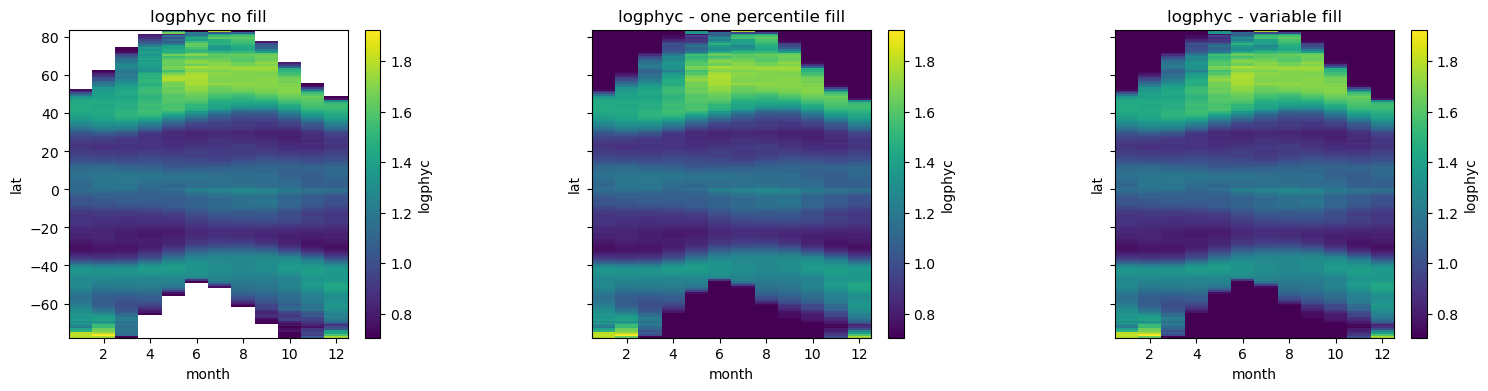

In [149]:
plot_lonmean('logphyc', dk_nonfill, dk_fillone, dk_fillvar)

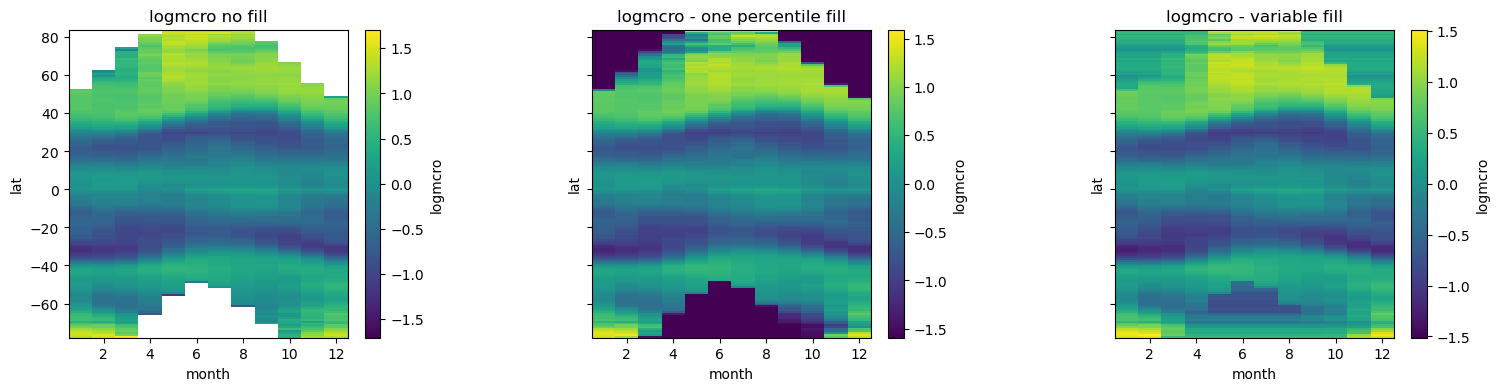

In [150]:
plot_lonmean('logmcro', dk_nonfill, dk_fillone, dk_fillvar)

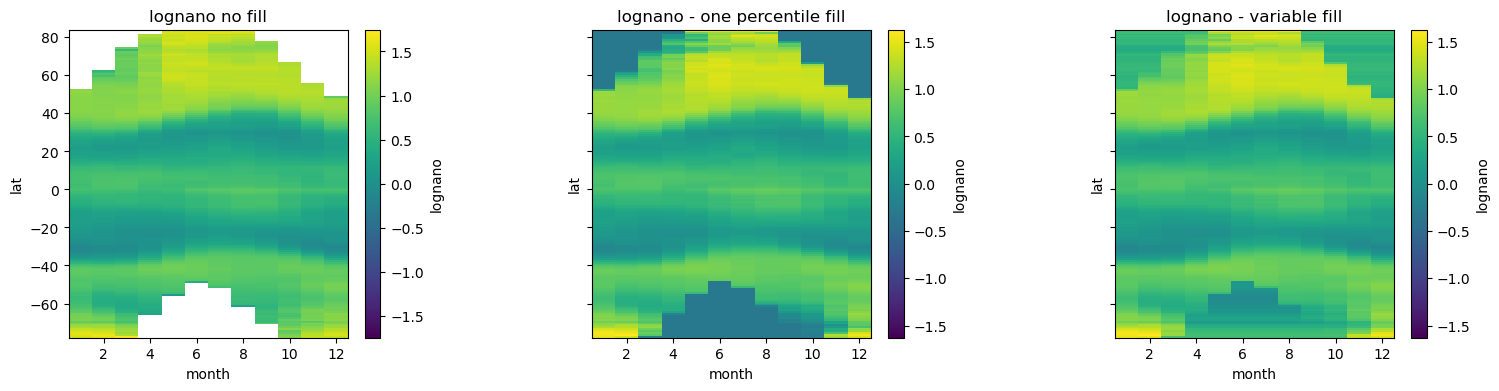

In [151]:
plot_lonmean('lognano', dk_nonfill, dk_fillone, dk_fillvar)

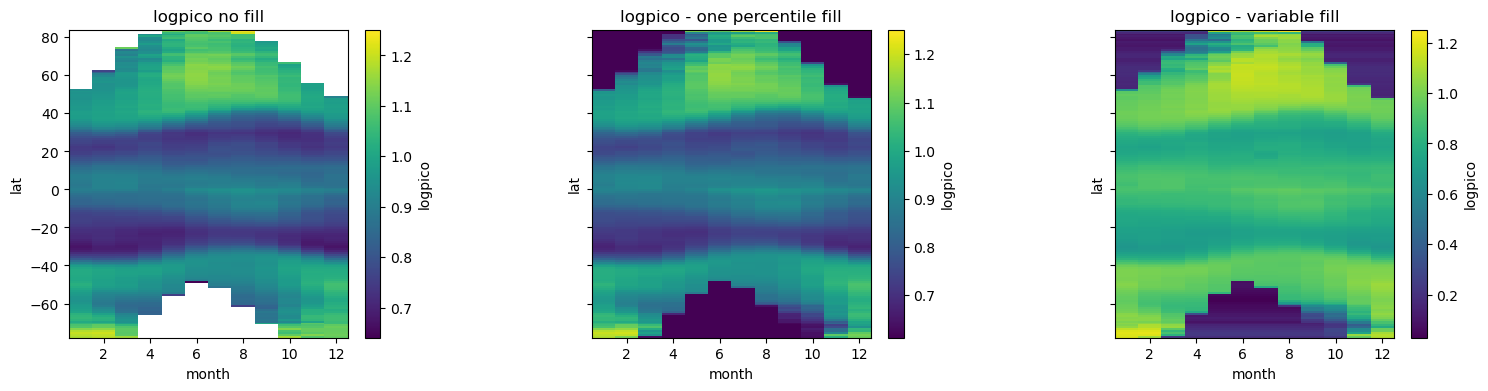

In [152]:
plot_lonmean('logpico', dk_nonfill, dk_fillone, dk_fillvar)

### Compare range of values

In [153]:
print("Copernicus Chla :",dc_nonfill['logchla'].min().round(decimals=6).values, dc_nonfill['logchla'].max().round(decimals=6).values)
print("MODIS+Hira Chla :",dm_nonfill['logchla'].min().round(decimals=6).values, dm_nonfill['logchla'].max().round(decimals=6).values)
print("Kostadinov Phyc :",dk_nonfill['logphyc'].min().round(decimals=6).values, dk_nonfill['logphyc'].max().round(decimals=6).values)

Copernicus Chla : -1.9436 1.574726
MODIS+Hira Chla : -2.249337 1.553117
Kostadinov Phyc : 0.105007 2.308786


In [154]:
print("Copernicus Micro :",dc_nonfill['logmcro'].min().round(decimals=6).values, dc_nonfill['logmcro'].max().round(decimals=6).values)
print("MODIS+Hira Micro :",dm_nonfill['logmcro'].min().round(decimals=6).values, dm_nonfill['logmcro'].max().round(decimals=6).values)
print("Kostadinov Micro :",dk_nonfill['logmcro'].min().round(decimals=6).values, dk_nonfill['logmcro'].max().round(decimals=6).values)

Copernicus Micro : -2.30103 1.65018
MODIS+Hira Micro : -4.249337 1.548753
Kostadinov Micro : -3.812041 1.944508


In [155]:
print("Copernicus Nano :",dc_nonfill['lognano'].min().round(decimals=6).values, dc_nonfill['lognano'].max().round(decimals=6).values)
print("MODIS+Hira Nano :",dm_nonfill['lognano'].min().round(decimals=6).values, dm_nonfill['lognano'].max().round(decimals=6).values)
print("Kostadinov Nano :",dk_nonfill['lognano'].min().round(decimals=6).values, dk_nonfill['lognano'].max().round(decimals=6).values)

Copernicus Nano : -2.30103 0.253608
MODIS+Hira Nano : -4.249337 1.370511
Kostadinov Nano : -1.459248 1.986939


In [156]:
print("Copernicus Pico :",dc_nonfill['logpico'].min().round(decimals=6).values, dc_nonfill['logpico'].max().round(decimals=6).values)
print("MODIS+Hira Pico :",dm_nonfill['logpico'].min().round(decimals=6).values, dm_nonfill['logpico'].max().round(decimals=6).values)
print("Kostadinov Pico :",dk_nonfill['logpico'].min().round(decimals=6).values, dk_nonfill['logpico'].max().round(decimals=6).values)

Copernicus Pico : -1.963355 1.0
MODIS+Hira Pico : -2.253702 -0.446883
Kostadinov Pico : -0.056135 1.673511


#### compare average values

In [157]:
print("Copernicus Chla :",dcm_nonfill['logchla'].min().round(decimals=6).values, dcm_nonfill['logchla'].max().round(decimals=6).values)
print("MODIS+Hira Chla :",dmm_nonfill['logchla'].min().round(decimals=6).values, dmm_nonfill['logchla'].max().round(decimals=6).values)
print("Kostadinov Chla :",dkm_nonfill['logphyc'].min().round(decimals=6).values, dkm_nonfill['logphyc'].max().round(decimals=6).values)

Copernicus Chla : -1.90631 1.363372
MODIS+Hira Chla : -1.978474 1.205182
Kostadinov Chla : 0.656308 2.156923


In [158]:
print("Copernicus Micro :",dcm_nonfill['logmcro'].min().round(decimals=6).values, dcm_nonfill['logmcro'].max().round(decimals=6).values)
print("MODIS+Hira Micro :",dmm_nonfill['logmcro'].min().round(decimals=6).values, dmm_nonfill['logmcro'].max().round(decimals=6).values)
print("Kostadinov Micro :",dkm_nonfill['logmcro'].min().round(decimals=6).values, dkm_nonfill['logmcro'].max().round(decimals=6).values)

Copernicus Micro : -2.30103 0.699733
MODIS+Hira Micro : -3.978474 1.19613
Kostadinov Micro : -1.601975 1.745843


In [159]:
print("Copernicus Nano :",dcm_nonfill['lognano'].min().round(decimals=6).values, dcm_nonfill['lognano'].max().round(decimals=6).values)
print("MODIS+Hira Nano :",dmm_nonfill['lognano'].min().round(decimals=6).values, dmm_nonfill['lognano'].max().round(decimals=6).values)
print("Kostadinov Nano :",dkm_nonfill['lognano'].min().round(decimals=6).values, dkm_nonfill['lognano'].max().round(decimals=6).values)

Copernicus Nano : -2.30103 -0.252791
MODIS+Hira Nano : -3.978474 0.733981
Kostadinov Nano : -0.297802 1.795206


In [160]:
print("Copernicus Pico :",dcm_nonfill['logpico'].min().round(decimals=6).values, dcm_nonfill['logpico'].max().round(decimals=6).values)
print("MODIS+Hira Pico :",dmm_nonfill['logpico'].min().round(decimals=6).values, dmm_nonfill['logpico'].max().round(decimals=6).values)
print("Kostadinov Pico :",dkm_nonfill['logpico'].min().round(decimals=6).values, dkm_nonfill['logpico'].max().round(decimals=6).values)

Copernicus Pico : -1.4881 0.860424
MODIS+Hira Pico : -1.982839 -0.49082
Kostadinov Pico : 0.53793 1.559249


#### Comapare variable fill values

In [161]:
print("Copernicus Chla :",dcm_fillvar['logchla'].min().round(decimals=6).values, dcm_fillvar['logchla'].max().round(decimals=6).values)
print("MODIS+Hira Chla :",dmm_fillvar['logchla'].min().round(decimals=6).values, dmm_fillvar['logchla'].max().round(decimals=6).values)
print("Kostadinov Chla :",dkm_fillvar['logphyc'].min().round(decimals=6).values, dkm_fillvar['logphyc'].max().round(decimals=6).values)

Copernicus Chla : -2.808917 0.790055
MODIS+Hira Chla : -2.895141 1.205182
Kostadinov Chla : 0.656308 2.082487


In [162]:
print("Copernicus Micro :",dcm_fillvar['logmcro'].min().round(decimals=6).values, dcm_fillvar['logmcro'].max().round(decimals=6).values)
print("MODIS+Hira Micro :",dmm_fillvar['logmcro'].min().round(decimals=6).values, dmm_fillvar['logmcro'].max().round(decimals=6).values)
print("Kostadinov Micro :",dkm_fillvar['logmcro'].min().round(decimals=6).values, dkm_fillvar['logmcro'].max().round(decimals=6).values)

Copernicus Micro : -2.728977 0.396422
MODIS+Hira Micro : -4.895141 1.19613
Kostadinov Micro : -3.15192 1.691728


In [163]:
print("Copernicus Nano :",dcm_fillvar['lognano'].min().round(decimals=6).values, dcm_fillvar['lognano'].max().round(decimals=6).values)
print("MODIS+Hira Nano :",dmm_fillvar['lognano'].min().round(decimals=6).values, dmm_fillvar['lognano'].max().round(decimals=6).values)
print("Kostadinov Nano :",dkm_fillvar['lognano'].min().round(decimals=6).values, dkm_fillvar['lognano'].max().round(decimals=6).values)

Copernicus Nano : -2.584076 -0.252791
MODIS+Hira Nano : -4.895141 0.733981
Kostadinov Nano : -1.087122 1.735011


In [164]:
print("Copernicus Pico :",dcm_fillvar['logpico'].min().round(decimals=6).values, dcm_fillvar['logpico'].max().round(decimals=6).values)
print("MODIS+Hira Pico :",dmm_fillvar['logpico'].min().round(decimals=6).values, dmm_fillvar['logpico'].max().round(decimals=6).values)
print("Kostadinov Pico :",dkm_fillvar['logpico'].min().round(decimals=6).values, dkm_fillvar['logpico'].max().round(decimals=6).values)

Copernicus Pico : -2.386074 0.006253
MODIS+Hira Pico : -2.899506 -0.49082
Kostadinov Pico : -0.109138 1.559249


### Cross plots

In [165]:
dcm_varfill = dcm_fillvar[['logchla','logmcro','lognano','logpico']]
dcm_varfill = dcm_varfill.rename({'logchla':'ChlaC','logmcro':'McroC','lognano':'NanoC','logpico':'PicoC'})
dmm_varfill = dmm_fillvar[['logchla','logmcro','lognano','logpico']]
dmm_varfill = dmm_varfill.rename({'logchla':'ChlaM','logmcro':'McroM','lognano':'NanoM','logpico':'PicoM'})
dkm_varfill = dkm_fillvar[['logphyc','logmcro','lognano','logpico']]
dkm_varfill = dkm_varfill.rename({'logphyc':'PhycK','logmcro':'McroK','lognano':'NanoK','logpico':'PicoK'})

In [166]:
dsat_varfill = xr.merge([dcm_varfill,dmm_varfill,dkm_varfill])
dfsat_varfill = dsat_varfill.to_dataframe()
dfsat_varfill = dfsat_varfill.dropna()
dfsat_varfill.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 35850 entries, (-77.5, -178.5) to (82.5, 81.5)
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ChlaC   35850 non-null  float32
 1   McroC   35850 non-null  float32
 2   NanoC   35850 non-null  float32
 3   PicoC   35850 non-null  float32
 4   ChlaM   35850 non-null  float32
 5   McroM   35850 non-null  float32
 6   NanoM   35850 non-null  float32
 7   PicoM   35850 non-null  float32
 8   PhycK   35850 non-null  float32
 9   McroK   35850 non-null  float32
 10  NanoK   35850 non-null  float32
 11  PicoK   35850 non-null  float32
dtypes: float32(12)
memory usage: 1.8 MB


In [167]:
corr_sat = np.round(dfsat_varfill.corr(), 2)

In [168]:
def corr_plot(corr_df, title, name):
    mask = np.triu(np.ones_like(corr_df, dtype=bool), k=1)  # hides upper triangle only
    # mask = np.triu(np.ones_like(corr_df, dtype=bool))  # hides upper triangle + diagonal
    
    f, ax = plt.subplots(figsize=(12, 12))
    
    heatmap = sns.heatmap(corr_df, 
                          ax=ax,
                          mask=mask,
                          square=True,
                          linewidths=.5,
                          cmap='coolwarm',
                          cbar_kws={'shrink': 0.7, 'ticks': np.linspace(-1, 1, 5)},
                          vmin=-1,
                          vmax=1,
                          annot=True,
                          annot_kws={'size': 12},
                          cbar=True)  # keep colorbar

    # # Make colorbar invisible
    # cbar = heatmap.collections[0].colorbar
    # cbar.remove()        # fully deleted
    # cbar.ax.set_visible(False)  # keeps space but hides it
    
    ax.set_title(title, fontsize=14, fontweight='bold')
    
    # # Set the y-tick labels to exclude the last correlation values
    # y_labels = corr_df.columns.to_list()
    # y_labels[0] = ""
    # ax.set_yticklabels(y_labels, rotation=0)
    
    # # Set the x-tick labels to exclude the last correlation values
    # x_labels = corr_chla.columns.to_list()
    # x_labels[-1] = ""
    # ax.set_xticklabels(x_labels)

    # add the column names as labels
    ax.set_yticklabels(corr_df.columns, rotation = 0)
    ax.set_xticklabels(corr_df.columns)
    ax.tick_params(labelsize=12)
    
    # Adjust style for visibility
    sns.set_style({'xtick.bottom': True}, {'ytick.left': True})
    # f.savefig(filepath + "copernicus/charts/" + name,dpi=200, bbox_inches='tight')
    
    plt.show()

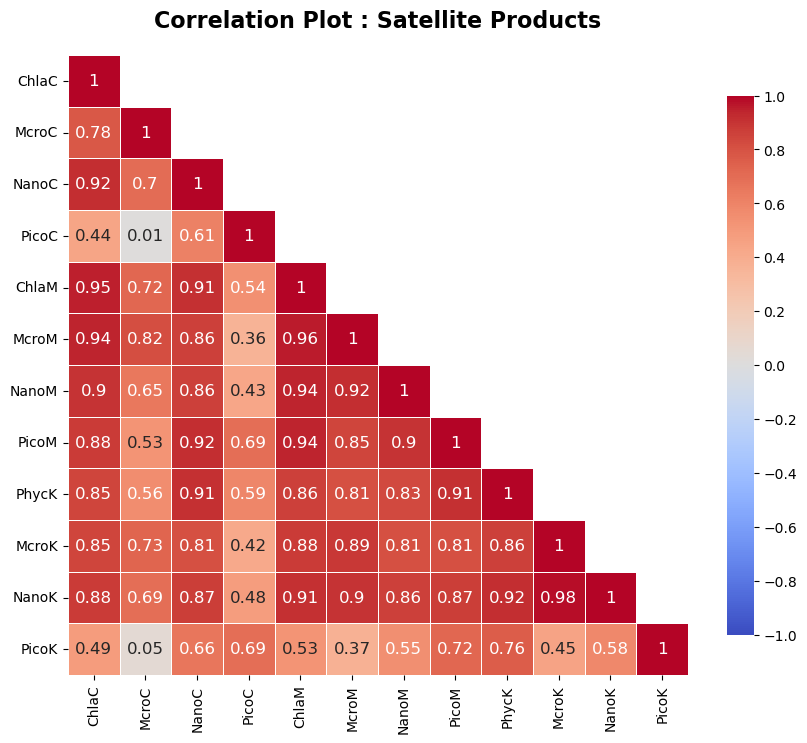

In [169]:
# Only mask upper triangle *excluding* diagonal
mask = np.triu(np.ones_like(corr_sat, dtype=bool), k=1)
# mask = np.zeros_like(corr_inputs, dtype=bool)
# mask[np.triu_indices_from(mask)]= True

f, ax = plt.subplots(figsize=(10, 10))

heatmap = sns.heatmap(corr_sat, ax=ax,
                      mask = mask,
                      square = True,
                      linewidths = .5,
                      cmap = 'coolwarm',
                      cbar = True,
                      cbar_kws = {'shrink': 0.7,'ticks' : np.linspace(-1, 1, 11)},
                      vmin = -1,
                      vmax = 1,
                      annot = True,
                      annot_kws = {'size': 12}
                     )
ax.set_title("Correlation Plot : Satellite Products", fontsize=16,fontweight='bold', pad=20)
#add the column names as labels
ax.set_yticklabels(corr_sat.columns, rotation = 0)
ax.set_xticklabels(corr_sat.columns, rotation=90)

sns.set_style({'xtick.bottom': True}, {'ytick.left': True})
# f.savefig(filepath + "copernicus/charts/corr_satellite.jpg",dpi=200, bbox_inches='tight')

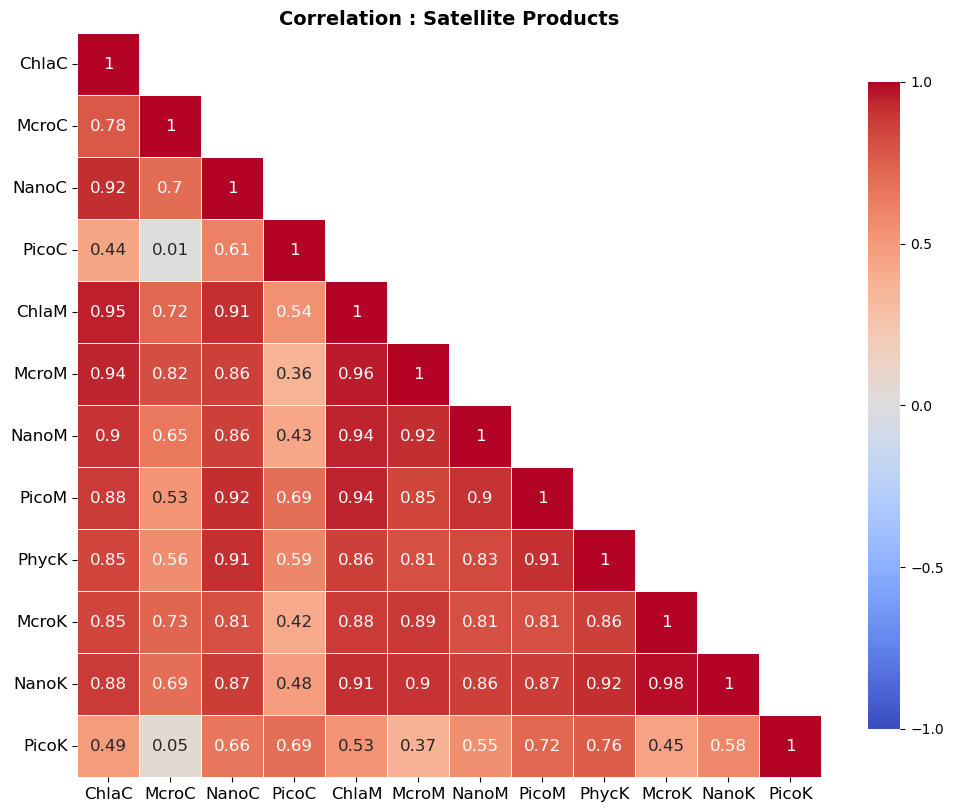

In [170]:
corr_plot(
    corr_df = corr_sat,
    title = "Correlation : Satellite Products",
    name = "corr_sat.jpg"
)

In [171]:
dcm_nofill = dcm_nonfill[['logchla','logmcro','lognano','logpico']]
dcm_nofill = dcm_nofill.rename({'logchla':'ChlaC','logmcro':'McroC','lognano':'NanoC','logpico':'PicoC'})
dmm_nofill = dmm_nonfill[['logchla','logmcro','lognano','logpico']]
dmm_nofill = dmm_nofill.rename({'logchla':'ChlaM','logmcro':'McroM','lognano':'NanoM','logpico':'PicoM'})
dkm_nofill = dkm_nonfill[['logphyc','logmcro','lognano','logpico']]
dkm_nofill = dkm_nofill.rename({'logphyc':'PhycK','logmcro':'McroK','lognano':'NanoK','logpico':'PicoK'})

In [172]:
dsat_nofill = xr.merge([dcm_nofill,dmm_nofill,dkm_nofill])
dfsat_nofill = dsat_nofill.to_dataframe()
dfsat_nofill = dfsat_nofill.dropna()
dfsat_nofill.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 35850 entries, (-179.5, -76.5) to (179.5, 77.5)
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ChlaC   35850 non-null  float64
 1   McroC   35850 non-null  float64
 2   NanoC   35850 non-null  float64
 3   PicoC   35850 non-null  float64
 4   ChlaM   35850 non-null  float32
 5   McroM   35850 non-null  float32
 6   NanoM   35850 non-null  float32
 7   PicoM   35850 non-null  float32
 8   PhycK   35850 non-null  float32
 9   McroK   35850 non-null  float32
 10  NanoK   35850 non-null  float32
 11  PicoK   35850 non-null  float32
dtypes: float32(8), float64(4)
memory usage: 2.3 MB


In [173]:
corr_sat_nofill = np.round(dfsat_nofill.corr(), 2)

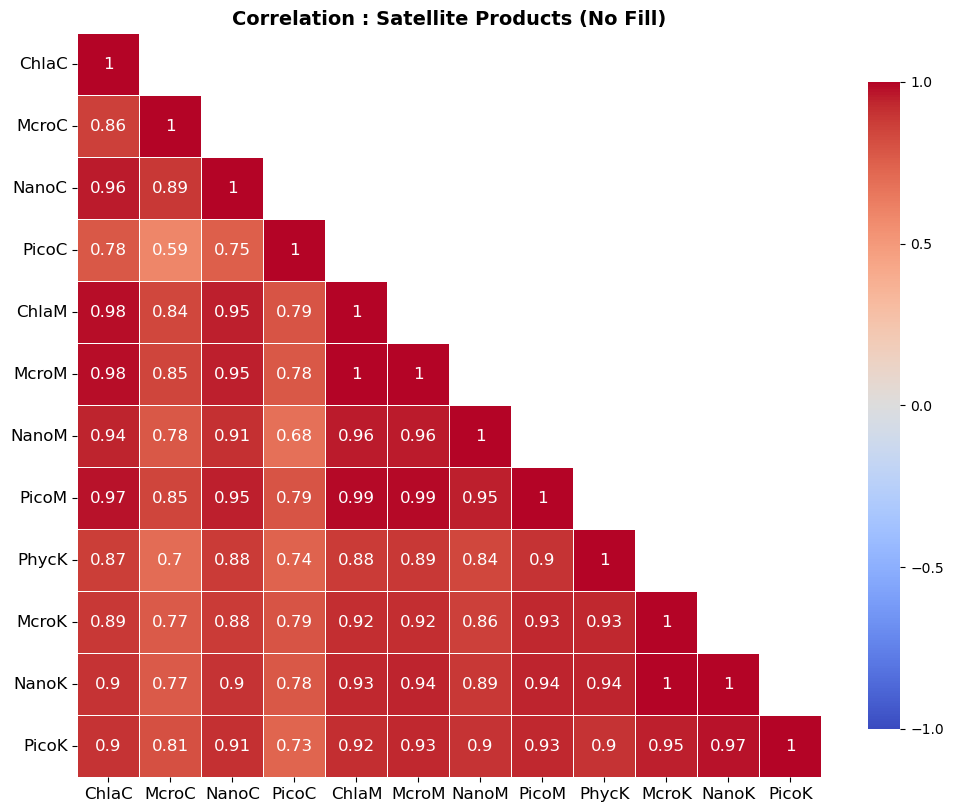

In [174]:
corr_plot(
    corr_df = corr_sat_nofill,
    title = "Correlation : Satellite Products (No Fill)",
    name = "corr_sat_nofill.jpg"
)

In [175]:
dcm_onefill = dcm_fillone[['logchla','logmcro','lognano','logpico']]
dcm_onefill = dcm_onefill.rename({'logchla':'ChlaC','logmcro':'McroC','lognano':'NanoC','logpico':'PicoC'})
dmm_onefill = dmm_fillone[['logchla','logmcro','lognano','logpico']]
dmm_onefill = dmm_onefill.rename({'logchla':'ChlaM','logmcro':'McroM','lognano':'NanoM','logpico':'PicoM'})
dkm_onefill = dkm_fillone[['logphyc','logmcro','lognano','logpico']]
dkm_onefill = dkm_onefill.rename({'logphyc':'PhycK','logmcro':'McroK','lognano':'NanoK','logpico':'PicoK'})

In [176]:
dsat_onefill = xr.merge([dcm_onefill,dmm_onefill,dkm_onefill])
dfsat_onefill = dsat_onefill.to_dataframe()
dfsat_onefill = dfsat_onefill.dropna()
dfsat_onefill.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 35926 entries, (-77.5, -178.5) to (83.5, -22.5)
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ChlaC   35926 non-null  float32
 1   McroC   35926 non-null  float32
 2   NanoC   35926 non-null  float32
 3   PicoC   35926 non-null  float32
 4   ChlaM   35926 non-null  float32
 5   McroM   35926 non-null  float32
 6   NanoM   35926 non-null  float32
 7   PicoM   35926 non-null  float32
 8   PhycK   35926 non-null  float32
 9   McroK   35926 non-null  float32
 10  NanoK   35926 non-null  float32
 11  PicoK   35926 non-null  float32
dtypes: float32(12)
memory usage: 1.8 MB


In [177]:
corr_sat_onefill = np.round(dfsat_onefill.corr(), 2)

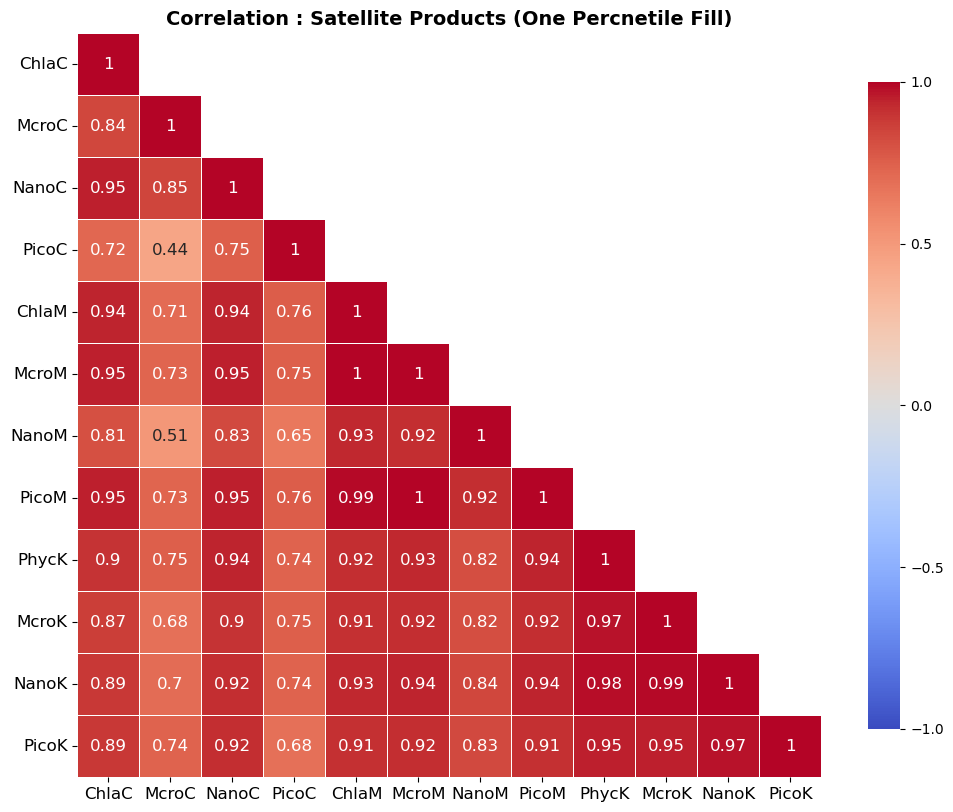

In [178]:
corr_plot(
    corr_df = corr_sat_onefill,
    title = "Correlation : Satellite Products (One Percnetile Fill)",
    name = "corr_sat_onefill.jpg"
)

In [180]:
corr_chla = np.round(dfsat_varfill.loc[:,['ChlaC','ChlaM','PhycK']].corr(), 2)

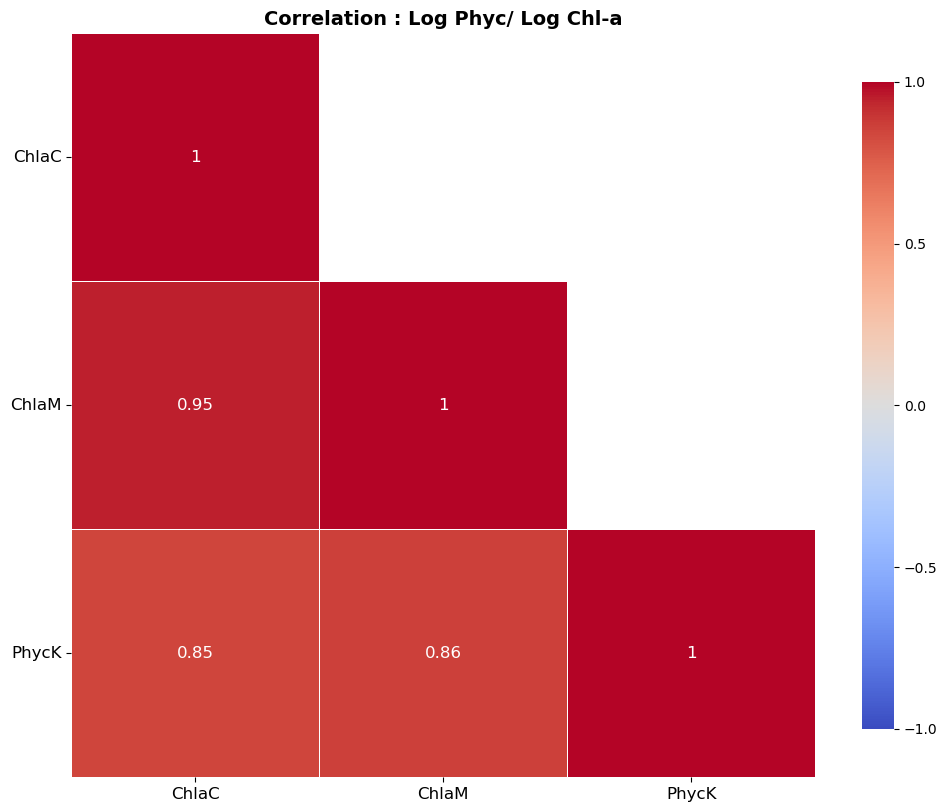

In [181]:
corr_plot(
    corr_df = corr_chla,
    title = "Correlation : Log Phyc/ Log Chl-a",
    name = "corr_chla.jpg"
)

In [182]:
corr_mcro = np.round(dfsat_varfill.loc[:,['McroC','McroM','McroK']].corr(), 2)

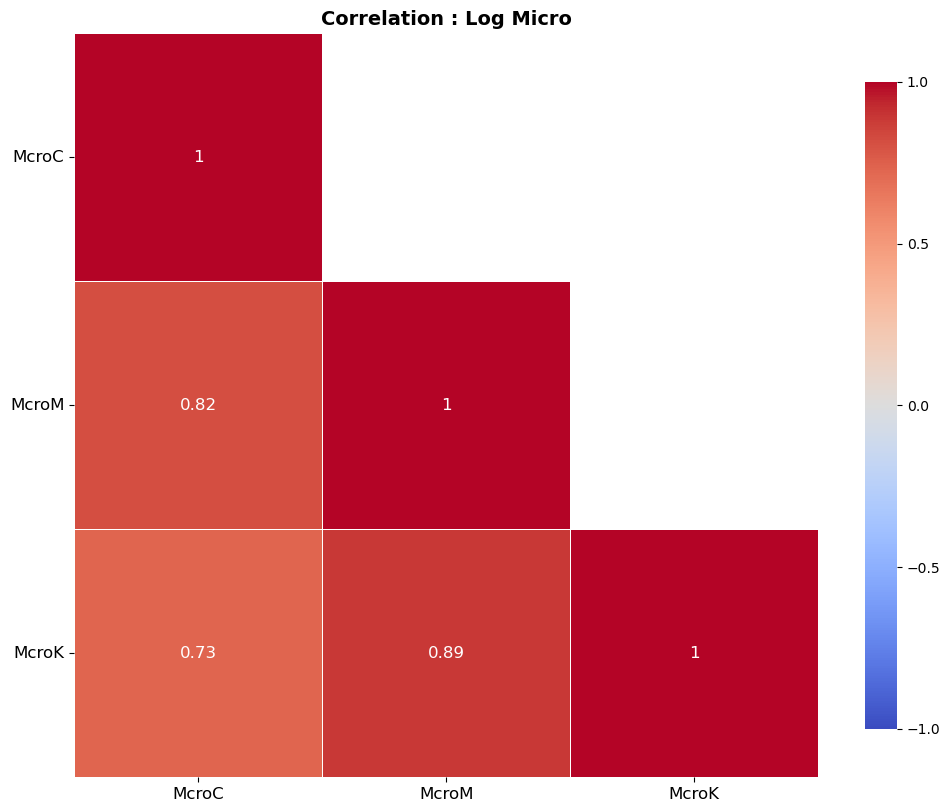

In [183]:
corr_plot(
    corr_df = corr_mcro,
    title = "Correlation : Log Micro",
    name = "corr_mcro.jpg"
)

In [184]:
corr_nano = np.round(dfsat_varfill.loc[:,['NanoC','NanoM','NanoK']].corr(), 2)

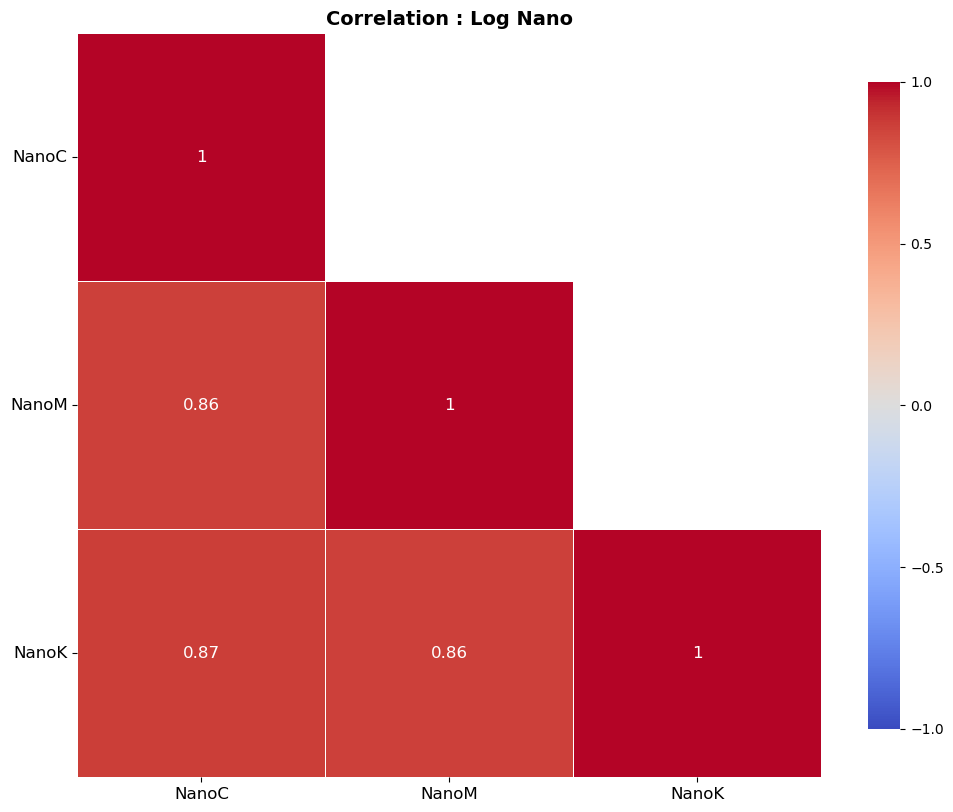

In [185]:
corr_plot(
    corr_df = corr_nano,
    title = "Correlation : Log Nano",
    name = "corr_nano.jpg"
)

In [186]:
corr_pico = np.round(dfsat_varfill.loc[:,['PicoC','PicoM','PicoK']].corr(), 2)

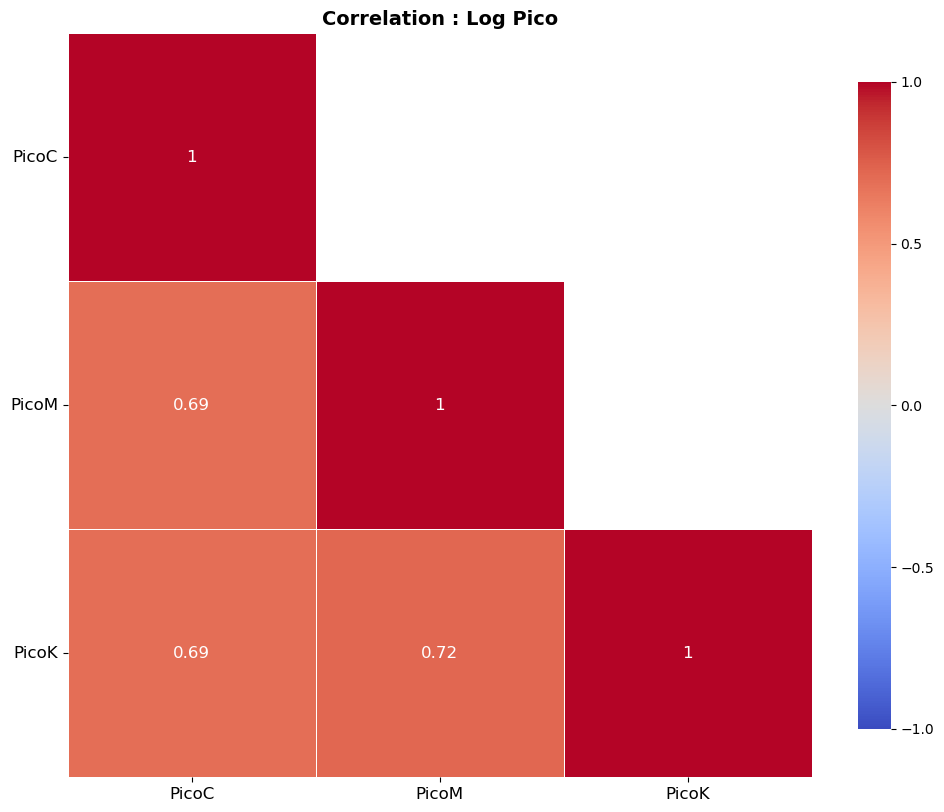

In [187]:
corr_plot(
    corr_df = corr_pico,
    title = "Correlation : Log Pico",
    name = "corr_pico.jpg"
)

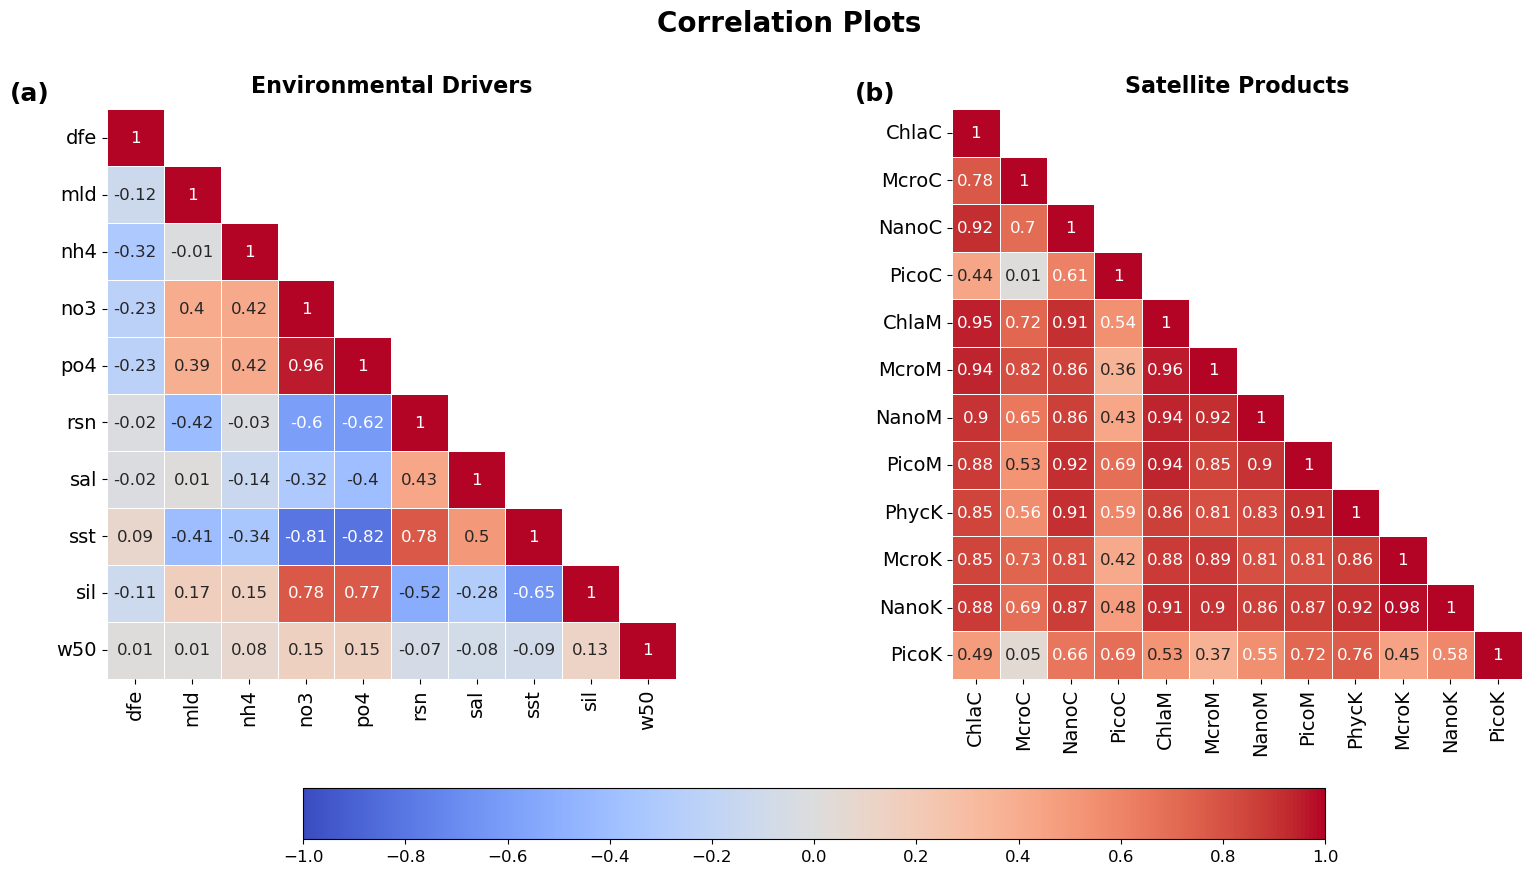

In [188]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- Mask for upper triangle excluding diagonal ---
mask_inputs = np.triu(np.ones_like(corr_inputs, dtype=bool), k=1)
mask_sat = np.triu(np.ones_like(corr_sat, dtype=bool), k=1)

# --- Create composite figure with 2 subplots side by side ---
fig, axes = plt.subplots(1, 2, figsize=(20, 10), gridspec_kw={'bottom':0.15})  # reserve space at bottom

# --- Shared heatmap settings ---
heatmap_kwargs = dict(
    square=True,
    linewidths=.5,
    cmap='coolwarm',
    vmin=-1, vmax=1,
    annot=True,
    annot_kws={'size': 12},
    cbar=False  # disable individual colorbars
)

# --- First heatmap: Environmental Drivers ---
hm1 = sns.heatmap(corr_inputs, ax=axes[0], mask=mask_inputs, **heatmap_kwargs)
axes[0].set_title("Environmental Drivers",
                  fontsize=16, fontweight='bold', pad=12)
axes[0].set_yticklabels(corr_inputs.columns, rotation=0, fontsize=14)
axes[0].set_xticklabels(corr_inputs.columns, rotation=90, fontsize=14)

# --- Second heatmap: Satellite Products ---
hm2 = sns.heatmap(corr_sat, ax=axes[1], mask=mask_sat, **heatmap_kwargs)
axes[1].set_title("Satellite Products",
                  fontsize=16, fontweight='bold', pad=12)
axes[1].set_yticklabels(corr_sat.columns, rotation=0, fontsize=14)
axes[1].set_xticklabels(corr_sat.columns, rotation=90, fontsize=14)

# --- Add subplot labels (a), (b) ---
labels = ['(a)', '(b)']
for ax, label in zip(axes, labels):
    ax.text(-0.1, 1.05, label, transform=ax.transAxes,
            fontsize=18, fontweight='bold', va='top', ha='right')

# --- Add one shared horizontal colorbar below both plots ---
cbar = fig.colorbar(hm2.collections[0], ax=axes,
                    orientation='horizontal',
                    fraction=0.07, pad=0.15,  # smaller pad so it sits just below
                    ticks=np.linspace(-1, 1, 11))
cbar.ax.tick_params(labelsize=12)

# --- Add overall suptitle ---
fig.suptitle("Correlation Plots", fontsize=20, fontweight='bold', y=0.98)

# --- Style and layout ---
sns.set_style({'xtick.bottom': True, 'ytick.left': True})
plt.tight_layout(rect=[0, 0.05, 1, 0.95])  # leave space for colorbar and suptitle

# --- Save if needed ---
fig.savefig(filepath + "copernicus/charts/composite_corr.jpg", dpi=200, bbox_inches='tight')

plt.show()